# Paper Model vs Improved Model — Retinal Vessel Segmentation on FIVES

**Base paper:** Guo et al., *"Channel Attention Residual U-Net for Retinal Vessel Segmentation"*, IEEE ICASSP 2021 ([arXiv:2004.03702](https://arxiv.org/abs/2004.03702)) — **CAR-UNet**
**Dataset:** FIVES (Jin et al., *Scientific Data* 2022) — 800 fundus images, 4 groups: AMD, Diabetic Retinopathy (DR), Glaucoma, Normal

This notebook compares the **paper model (CAR-UNet)** with our **improved model**, explains *what* was improved and *how*, shows the code of every improvement, and proves each claim with test results.

### Summary at a glance (200 test images, mean of 3 training seeds)

| Metric | Paper model (CAR-UNet) | **Improved model** | Change |
|---|---|---|---|
| Dice (overlap with expert tracing) | 0.8382 | **0.8436** | **+0.54 points** |
| Sensitivity (vessel pixels found) | 0.8310 | **0.8465** | **+1.55 points** |
| clDice (vessel connectivity) | 0.8626 | **0.8751** | **+1.25 points** |
| AUC-ROC | 0.9860 | **0.9878** | +0.17 points |
| Dice against the 1024×1024 ground truth (thin vessels visible) | 0.8572 | **0.8796** | **+2.24 points** |

### The four improvements

| # | Weakness of the paper | Our improvement |
|---|---|---|
| 1 | Channel attention only — the network learns *which* features matter, never *where* vessels are | **Dual attention**: channel attention (average + max pooling) + spatial attention |
| 2 | Pixel-wise BCE loss — breaking a thin vessel costs almost nothing | **clDice loss**: compares vessel *skeletons*, so connectivity is rewarded |
| 3 | Small, low-resolution input — thin capillaries disappear | **1024×1024 working resolution** instead of 512×512 |
| 4 | Fixed 0.5 decision threshold | **Threshold chosen on the validation set** (test-time augmentation also tested) |

Sections 1–6 explain the data and each improvement with its code; Sections 7–14 compare the two models; Section 15 lists the key findings.

In [1]:
# ---- Setup -------------------------------------------------------------------------------------------------
import os, sys, json, time, inspect
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
sys.path.insert(0, os.path.abspath("."))
import torch                     # import torch before numpy (DLL load order on this machine)
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
from scipy.ndimage import distance_transform_edt

from src.car_unet import CARUNet, MECA, DualPoolChannelAttention, SpatialAttention, DualAttention
from src.losses import soft_skeleton, SoftClDiceLoss, BCEDiceClDiceLoss, DiceLoss
from src.metrics import compute_fov_metrics, compute_cldice
from src.data_loader_fives import load_fives_image_pairs, get_disease_code, DISEASE_NAMES
from scripts.train_fives import MODEL_SPECS, MODEL_RESOLUTION, prepare_eval_item, predict_item
from scripts.evaluate_post import predict_with_flips
from scripts.summarize_post import selected_setting

NOTEBOOK_START = time.time()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device, torch.cuda.get_device_name(0) if torch.cuda.is_available() else "")

RUNS = "results/runs"
SEEDS = [0, 1, 2]
PAPER, IMPROVED = "car_unet", "car_unet_da_cldice_1024"
LABEL = {PAPER: "Paper model (CAR-UNet)", IMPROVED: "Improved model"}
COLORS = {"Paper model (CAR-UNet)": "#4C72B0", "Improved model": "#DD8452"}
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.3})

def load_model(key, seed):
    _, cls, kwargs, _ = MODEL_SPECS[key]
    model = cls(in_channels=1, out_channels=1, base_filters=64, **kwargs).to(device)
    ckpt = torch.load(f"models/{key}_seed{seed}.pt", map_location=device, weights_only=False)
    model.load_state_dict(ckpt["model_state_dict"])
    return model.eval()

def per_image(key, seed, setting="base"):
    """Saved per-image test metrics of one trained run (setting = prediction setting of Improvement 4)."""
    if setting == "base":
        return pd.read_csv(f"{RUNS}/{key}_seed{seed}/test_metrics_per_image.csv").set_index("filename")
    return pd.read_csv(f"{RUNS}/{key}_seed{seed}/post/test_metrics_{setting}.csv").set_index("filename")

def improved_setting(seed):
    post = json.load(open(f"{RUNS}/{IMPROVED}_seed{seed}/post/summary.json"))
    s = selected_setting(post)                      # chosen on the VALIDATION set only
    return s, post["settings"][s]["threshold"]

def paper_results(seed):
    return per_image(PAPER, seed)

def improved_results(seed):
    return per_image(IMPROVED, seed, improved_setting(seed)[0])

paper_model = load_model(PAPER, 0)
improved_model = load_model(IMPROVED, 0)
n_paper = sum(p.numel() for p in paper_model.parameters())
n_improved = sum(p.numel() for p in improved_model.parameters())
print(f"Paper model parameters:    {n_paper:,}")
print(f"Improved model parameters: {n_improved:,}  (+{n_improved - n_paper:,}, +{100 * (n_improved - n_paper) / n_paper:.3f}%)")

Device: cuda NVIDIA GeForce RTX 4050 Laptop GPU
Paper model parameters:    32,435,132
Improved model parameters: 32,436,406  (+1,274, +0.004%)


---
## 1. Dataset and evaluation protocol

- **FIVES**: 800 colour fundus images (2048×2048) with expert vessel tracings; 600 for training, 200 for testing (50 per disease).
- The 600 training images are split **by disease** into 480 for training and 120 for validation (30 per disease), with a fixed seed.
- Both models were trained with **identical settings** (same script, same data, same augmentation, same optimiser, 30 epochs) and **3 different random seeds** each, so differences are caused by the improvements, not by luck.
- All metrics are computed **inside the field of view (FOV)** of the retina, per image, then averaged over the 200 test images.
- **Dice** measures overlap with the expert tracing; **sensitivity** the fraction of vessel pixels found; **clDice** how well the vessel *centrelines / connectivity* are preserved (thin vessels count as much as thick ones).

          train  validation  test
AMD         120          30    50
DR          120          30    50
Glaucoma    120          30    50
Normal      120          30    50
Total       480         120   200


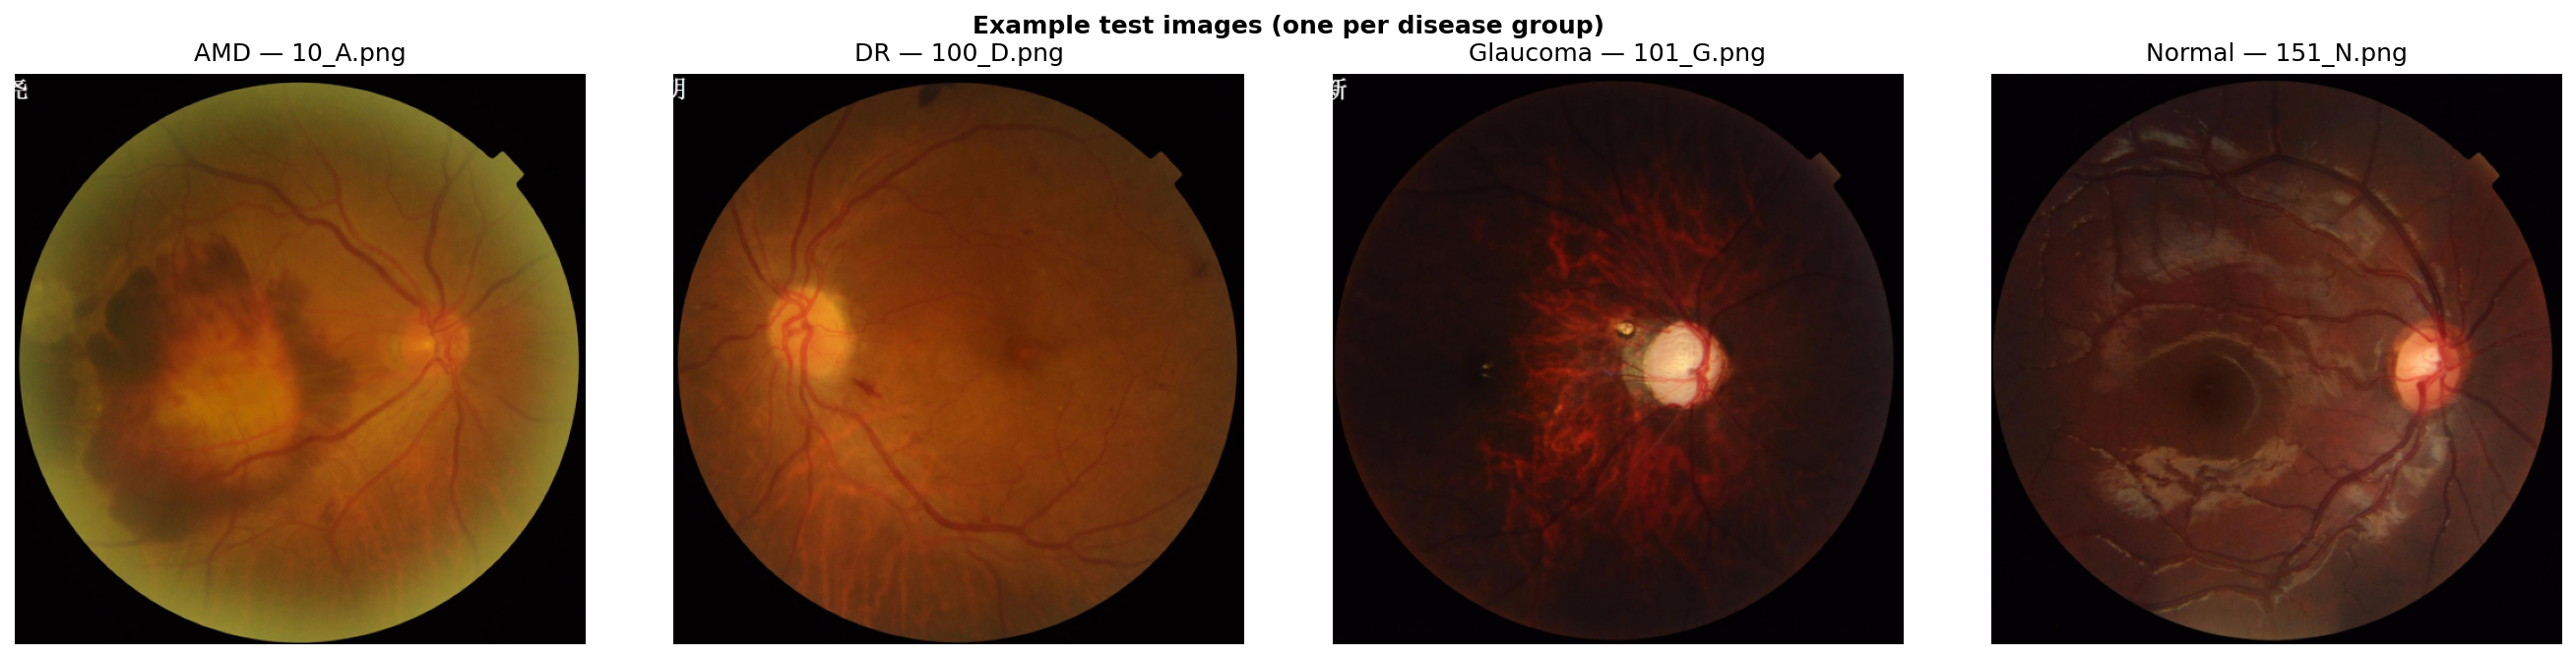

In [2]:
train = load_fives_image_pairs("data/FIVES_resized", "train")
val = load_fives_image_pairs("data/FIVES_resized", "val")
test = load_fives_image_pairs("data/FIVES_resized", "test")
counts = pd.DataFrame({name: pd.Series([DISEASE_NAMES[get_disease_code(p[0])] for p in pairs]).value_counts()
                       for name, pairs in [("train", train), ("validation", val), ("test", test)]})
counts.loc["Total"] = counts.sum()
print(counts.to_string())

fig, ax = plt.subplots(1, 4, figsize=(18, 4.5))
for a, code_ in zip(ax, ["A", "D", "G", "N"]):
    img_path = [p[0] for p in test if get_disease_code(p[0]) == code_][0]
    a.imshow(cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB))
    a.set_title(f"{DISEASE_NAMES[code_]} — {os.path.basename(img_path)}")
    a.axis("off")
plt.suptitle("Example test images (one per disease group)", fontweight="bold")
plt.tight_layout()
plt.show()

---
## 2. The paper model (CAR-UNet) and its weaknesses

CAR-UNet is a U-Net whose convolution blocks are replaced by residual blocks with **channel attention (MECA)**, with MECA also applied on the skip connections. Its channel attention, as used in our paper-model implementation, is shown below: it computes **one weight per feature channel** from the channel's average — it says *which* features matter, but gives **no information about where** in the image the vessels are.

| # | Weakness of the paper | Evidence |
|---|---|---|
| W1 | Channel attention only — no spatial (*where*) information | Paper §2.2; missed thin vessels in our error maps |
| W2 | Pixel-wise BCE loss only — vessels are ~8% of pixels and nothing rewards *connected* vessels | Paper §3.2; broken capillaries at vessel tips |
| W3 | Designed for small low-resolution images; on FIVES we had to shrink 2048×2048 images to 512×512 | Missed vessels are almost all thin |
| W4 | Fixed 0.5 threshold, single prediction | Paper §3.3 |
| W5 | Weak evaluation: 20 training images, no Dice / connectivity / per-disease results, single run | Paper Tables 1–3 |

In [3]:
print("=== Paper model: channel attention (MECA) — src/car_unet.py ===\n")
print(inspect.getsource(MECA))

=== Paper model: channel attention (MECA) — src/car_unet.py ===

class MECA(nn.Module):
    """
    Modified Efficient Channel Attention (MECA) Module.
    Uses 1D convolution with adaptive kernel size across channels to capture
    local cross-channel interactions without dimensionality reduction.
    Equation: k = |(log2(C) + b) / gamma|_odd
    """
    def __init__(self, channels: int, gamma: int = 2, b: int = 1, k_size: int = None):
        super().__init__()
        if k_size is None:
            t = int(abs((math.log2(max(channels, 2)) + b) / gamma))
            k_size = t if t % 2 == 1 else t + 1
            k_size = max(3, k_size) # ensure minimum odd kernel size >= 3
        self.k_size = k_size
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.conv = nn.Conv1d(1, 1, kernel_size=k_size, padding=(k_size - 1) // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, C, H, W)
        y = self.avg_poo

---
## 3. Improvement 1 — Dual attention (fixes W1)

**What:** every attention module of CAR-UNet (inside all residual blocks and on all skip connections) is replaced by **Dual Attention**:
1. **Channel attention from average- *and* max-pooled descriptors** through a shared 1D convolution (the paper's own MECA equation 3, which uses both poolings);
2. followed by **spatial attention** (CBAM, Woo et al. 2018): the per-pixel average and maximum over channels are combined by a 7×7 convolution into **one weight per pixel**, so the network learns *where* vessels are.

**Cost:** only ~1,300 extra parameters (+0.004%). The exact code used in training is printed below.

In [4]:
for obj in [DualPoolChannelAttention, SpatialAttention, DualAttention]:
    print(inspect.getsource(obj))

class DualPoolChannelAttention(nn.Module):
    """
    Channel attention from both average-pooled and max-pooled descriptors passed through a
    shared 1D convolution and added (Guo et al. 2021, Eq. 3). Kernel size follows the same
    adaptive rule as MECA above so that only the pooling changes.
    """
    def __init__(self, channels: int, gamma: int = 2, b: int = 1):
        super().__init__()
        t = int(abs((math.log2(max(channels, 2)) + b) / gamma))
        k_size = max(3, t if t % 2 == 1 else t + 1)
        self.conv = nn.Conv1d(1, 1, kernel_size=k_size, padding=(k_size - 1) // 2, bias=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        avg = x.mean(dim=(2, 3)).unsqueeze(1)    # (B, 1, C)
        mx = x.amax(dim=(2, 3)).unsqueeze(1)     # (B, 1, C)
        w = torch.sigmoid(self.conv(avg) + self.conv(mx))  # shared conv, channel-wise addition
        return x * w.squeeze(1)[:, :, None, None]

class SpatialAttention(nn.Module):
    """
    Spatial attenti

**What does the spatial attention look at?** Below, a test image patch goes through the improved model, and we show the spatial attention weight map of the first encoder block (one weight per pixel). The map clearly **traces the vessel tree, including thin vessels** — the network has learned *where* the vessels are, which channel attention alone cannot express. (In this first block vessel pixels receive slightly *lower* weights than background, i.e. they appear as darker lines: the block treats vessel and background pixels differently.)

Mean spatial-attention weight: vessel-like (darkest 20%) pixels 0.852 vs other pixels 0.908 -> the attention map separates vessels from background


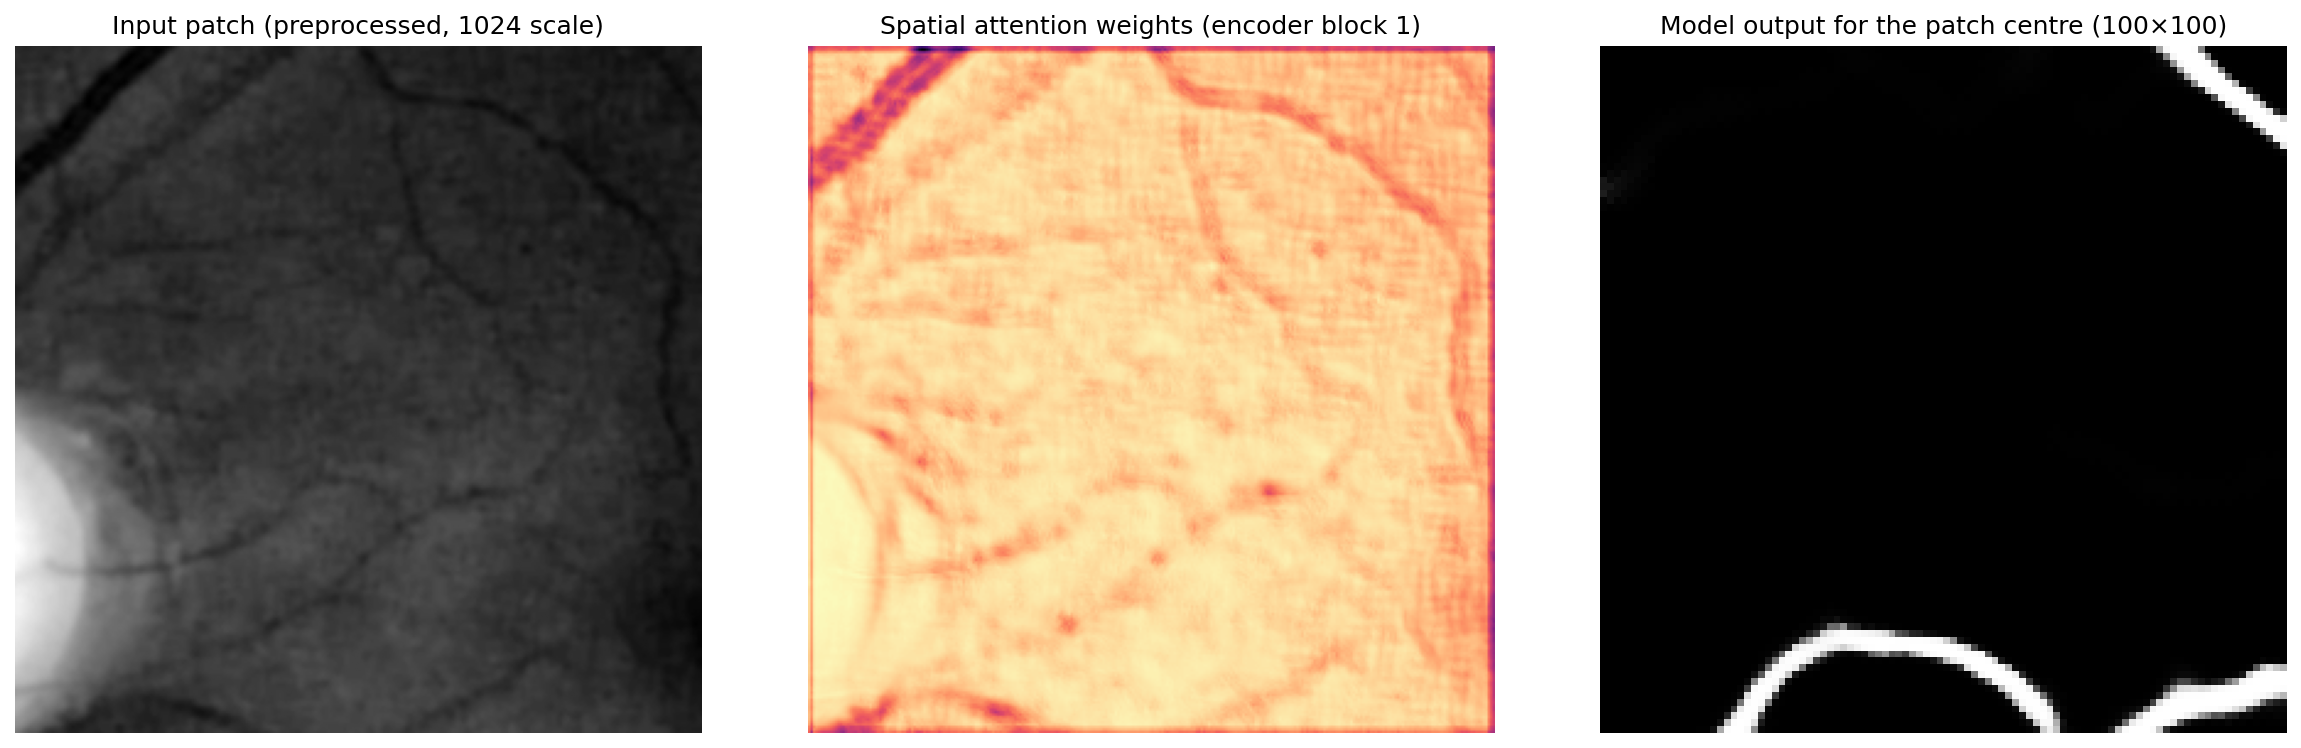

In [5]:
captured = {}
hook = improved_model.enc1.meca.spatial.register_forward_hook(lambda m, inp, out: captured.update(x=inp[0].detach()))
item = prepare_eval_item("data/FIVES_resized/test/images/104_G.png", "data/FIVES_resized/test/masks/104_G.png", 1024)
prep = item["prep"].astype(np.float32) / 255.0
y0, x0 = 300, 330                                      # a 284x284 patch near the optic disc with many vessels
patch = prep[y0:y0 + 284, x0:x0 + 284]
with torch.no_grad():
    out = improved_model(torch.from_numpy(patch)[None, None].to(device))
    x = captured["x"]
    sp = improved_model.enc1.meca.spatial
    att = torch.sigmoid(sp.conv(torch.cat([x.mean(1, keepdim=True), x.amax(1, keepdim=True)], 1)))[0, 0].cpu().numpy()
hook.remove()
gt_patch = item["gt_hi"][y0 + 92:y0 + 192, x0 + 92:x0 + 192]

fig, ax = plt.subplots(1, 3, figsize=(16, 5))
ax[0].imshow(patch[2:-2, 2:-2], cmap="gray"); ax[0].set_title("Input patch (preprocessed, 1024 scale)")
ax[1].imshow(att, cmap="magma"); ax[1].set_title("Spatial attention weights (encoder block 1)")
ax[2].imshow(out[0, 0].cpu().numpy(), cmap="gray"); ax[2].set_title("Model output for the patch centre (100×100)")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()
dark = patch[2:-2, 2:-2] < np.percentile(patch, 20)
print(f"Mean spatial-attention weight: vessel-like (darkest 20%) pixels {att[dark].mean():.3f} vs other pixels {att[~dark].mean():.3f} "
      f"-> the attention map separates vessels from background")

---
## 4. Improvement 2 — clDice loss (fixes W2)

**What:** training loss = 0.5·BCE + 0.5·[0.5·Dice + 0.5·**clDice**]. clDice (Shit et al., CVPR 2021) compares the **skeletons** (centrelines) of the prediction and the expert tracing, using a differentiable "soft skeleton". If a thin vessel is broken, a whole piece of its skeleton disappears, so the loss rises clearly — with plain Dice, a broken thin vessel costs only a few pixels.

In [6]:
for obj in [soft_skeleton, SoftClDiceLoss, BCEDiceClDiceLoss]:
    print(inspect.getsource(obj))

def soft_skeleton(img: torch.Tensor, iterations: int = 10) -> torch.Tensor:
    """Differentiable morphological skeleton of a probability map (Shit et al., CVPR 2021)."""
    skel = F.relu(img - _soft_dilate(_soft_erode(img)))
    for _ in range(iterations):
        img = _soft_erode(img)
        delta = F.relu(img - _soft_dilate(_soft_erode(img)))
        skel = skel + F.relu(delta - skel * delta)
    return skel

class SoftClDiceLoss(nn.Module):
    """
    clDice loss (Shit et al., "clDice - a Novel Topology-Preserving Loss Function for Tubular
    Structure Segmentation", CVPR 2021). Compares vessel SKELETONS instead of pixels, so
    breaking a thin vessel or missing a capillary costs as much as missing a thick vessel.
        Tprec = |S(pred) * GT| / |S(pred)|,  Tsens = |S(GT) * pred| / |S(GT)|
        clDice = 2 * Tprec * Tsens / (Tprec + Tsens),  loss = 1 - clDice
    """
    def __init__(self, iterations: int = 10, smooth: float = 1.0):
        super().__init__()
        self.

**Demonstration on a synthetic vessel image:** we (a) cut a *thin* vessel and (b) trim the end of a *thick* vessel, and compare how much Dice loss and clDice loss increase.

Thin vessel cut       :  20 pixels removed | Dice loss 0.0136 | clDice loss 0.0617
Thick vessel trimmed  :  40 pixels removed | Dice loss 0.0276 | clDice loss 0.0238

A broken thin vessel is penalised 4.5x more by clDice than by Dice.


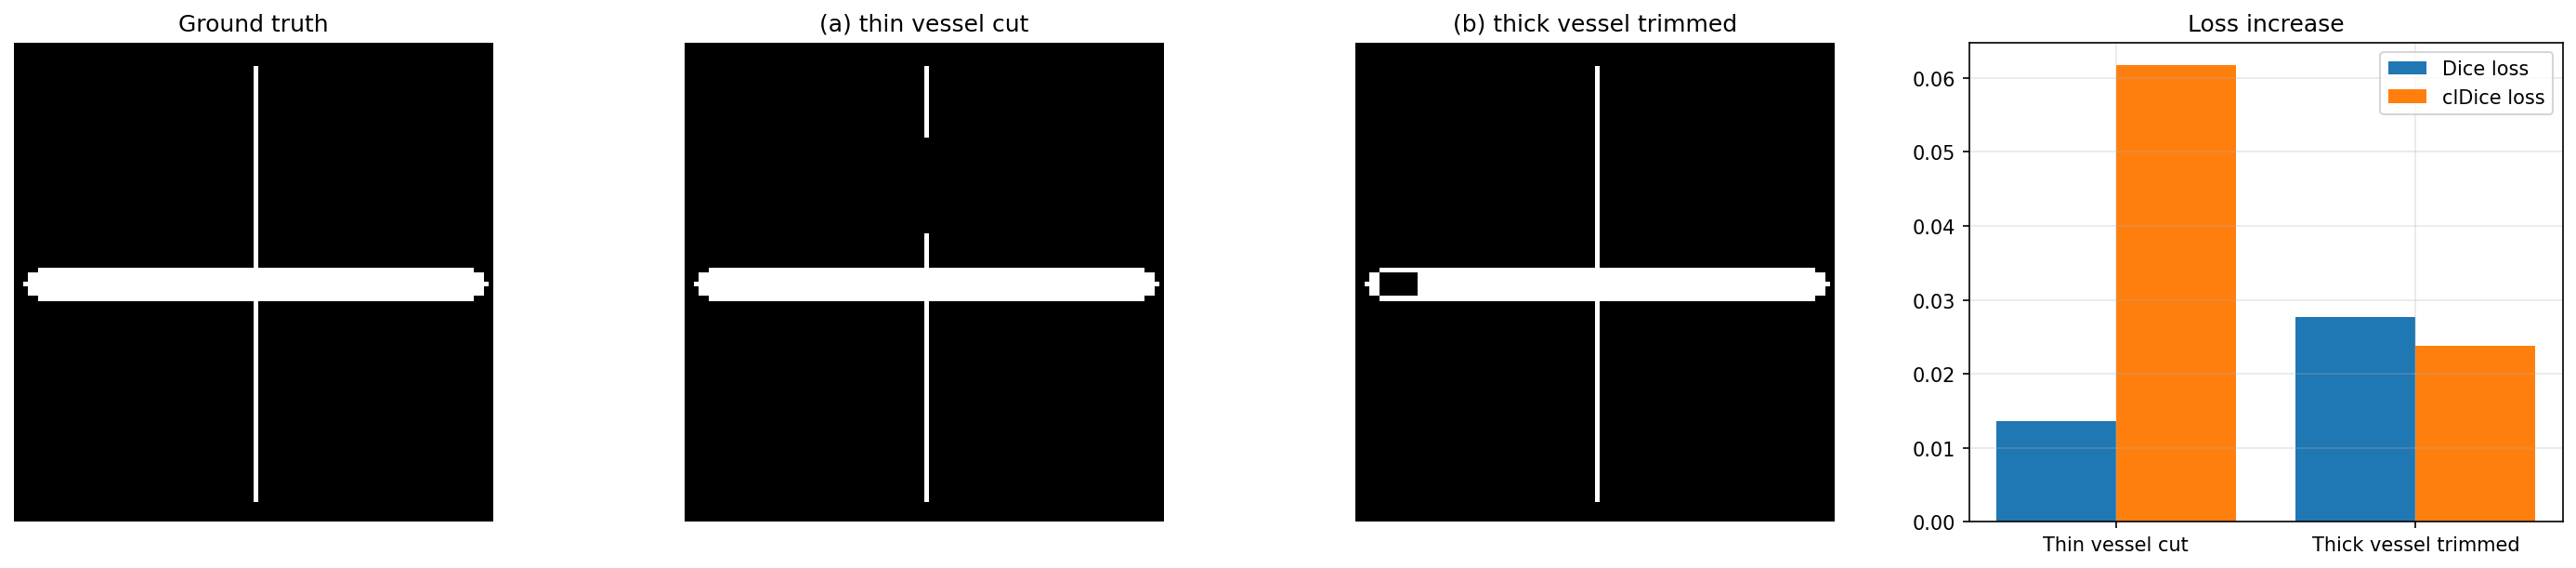

In [7]:
gt = np.zeros((100, 100), np.float32)
cv2.line(gt, (5, 50), (95, 50), 1, 5)       # thick vessel
cv2.line(gt, (50, 5), (50, 95), 1, 1)       # thin vessel
cut_thin = gt.copy(); cut_thin[20:40, 49:52] = 0
trim_thick = gt.copy(); trim_thick[48:53, 5:13] = 0
T = lambda a: torch.from_numpy(a)[None, None]
dice_l, cl_l = DiceLoss(), SoftClDiceLoss()
cases = {"Thin vessel cut": cut_thin, "Thick vessel trimmed": trim_thick}
res = {k: (int(gt.sum() - v.sum()), dice_l(T(v), T(gt)).item(), cl_l(T(v), T(gt)).item()) for k, v in cases.items()}

fig, ax = plt.subplots(1, 4, figsize=(19, 4.2))
for a, (title, im) in zip(ax[:3], [("Ground truth", gt), ("(a) thin vessel cut", cut_thin), ("(b) thick vessel trimmed", trim_thick)]):
    a.imshow(im, cmap="gray"); a.set_title(title); a.axis("off")
xs = np.arange(2)
ax[3].bar(xs - 0.2, [res[k][1] for k in cases], 0.4, label="Dice loss")
ax[3].bar(xs + 0.2, [res[k][2] for k in cases], 0.4, label="clDice loss")
ax[3].set_xticks(xs); ax[3].set_xticklabels(list(cases)); ax[3].set_title("Loss increase"); ax[3].legend()
plt.tight_layout(); plt.show()
for k, (px, d, c) in res.items():
    print(f"{k:22s}: {px:3d} pixels removed | Dice loss {d:.4f} | clDice loss {c:.4f}")
print(f"\nA broken thin vessel is penalised {res['Thin vessel cut'][2] / res['Thin vessel cut'][1]:.1f}x more by clDice than by Dice.")

---
## 5. Improvement 3 — 1024×1024 working resolution (fixes W3)

**What:** FIVES images are 2048×2048. The paper model works on 512×512 copies, where the finest capillaries are only a fraction of a pixel wide and vanish. The improved model is **trained and run on 1024×1024 copies**. For a fair comparison, its prediction is **downsampled and scored on exactly the same 512×512 ground truth** as the paper model (Section 12 additionally scores both against the 1024×1024 ground truth). The code that prepares an image at the model's resolution and returns the 512 prediction:

In [8]:
for obj in [prepare_eval_item, predict_item]:
    print(inspect.getsource(obj))

def prepare_eval_item(img_path, mask_path, model_res=512, keep_raw=False):
    """
    Loads one evaluation image (paths point to the 512x512 copy) in a compact uint8 form:
      prep / fov_in : model input + FOV at the model's working resolution
      gt / fov      : 512x512 ground truth + FOV used for the official metrics
      gt_hi / fov_hi: ground truth + FOV at the model resolution (only when model_res != 512)
    """
    raw = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    gt = (cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE) > 128).astype(np.uint8)
    fov = generate_fov_mask(raw).astype(np.uint8)
    item = {"gt": gt, "fov": fov}
    if model_res == EVAL_RESOLUTION:
        item.update(prep=preprocess_image_uint8(raw), fov_in=fov)
    else:
        hi_dir = f"FIVES_{model_res}"
        hi_img = img_path.replace("FIVES_resized", hi_dir)
        hi_raw = cv2.cvtColor(cv2.imread(hi_img), cv2.COLOR_BGR2RGB)
        fov_hi = generate_fov_mask(hi_raw).astype(np.uint8)
       

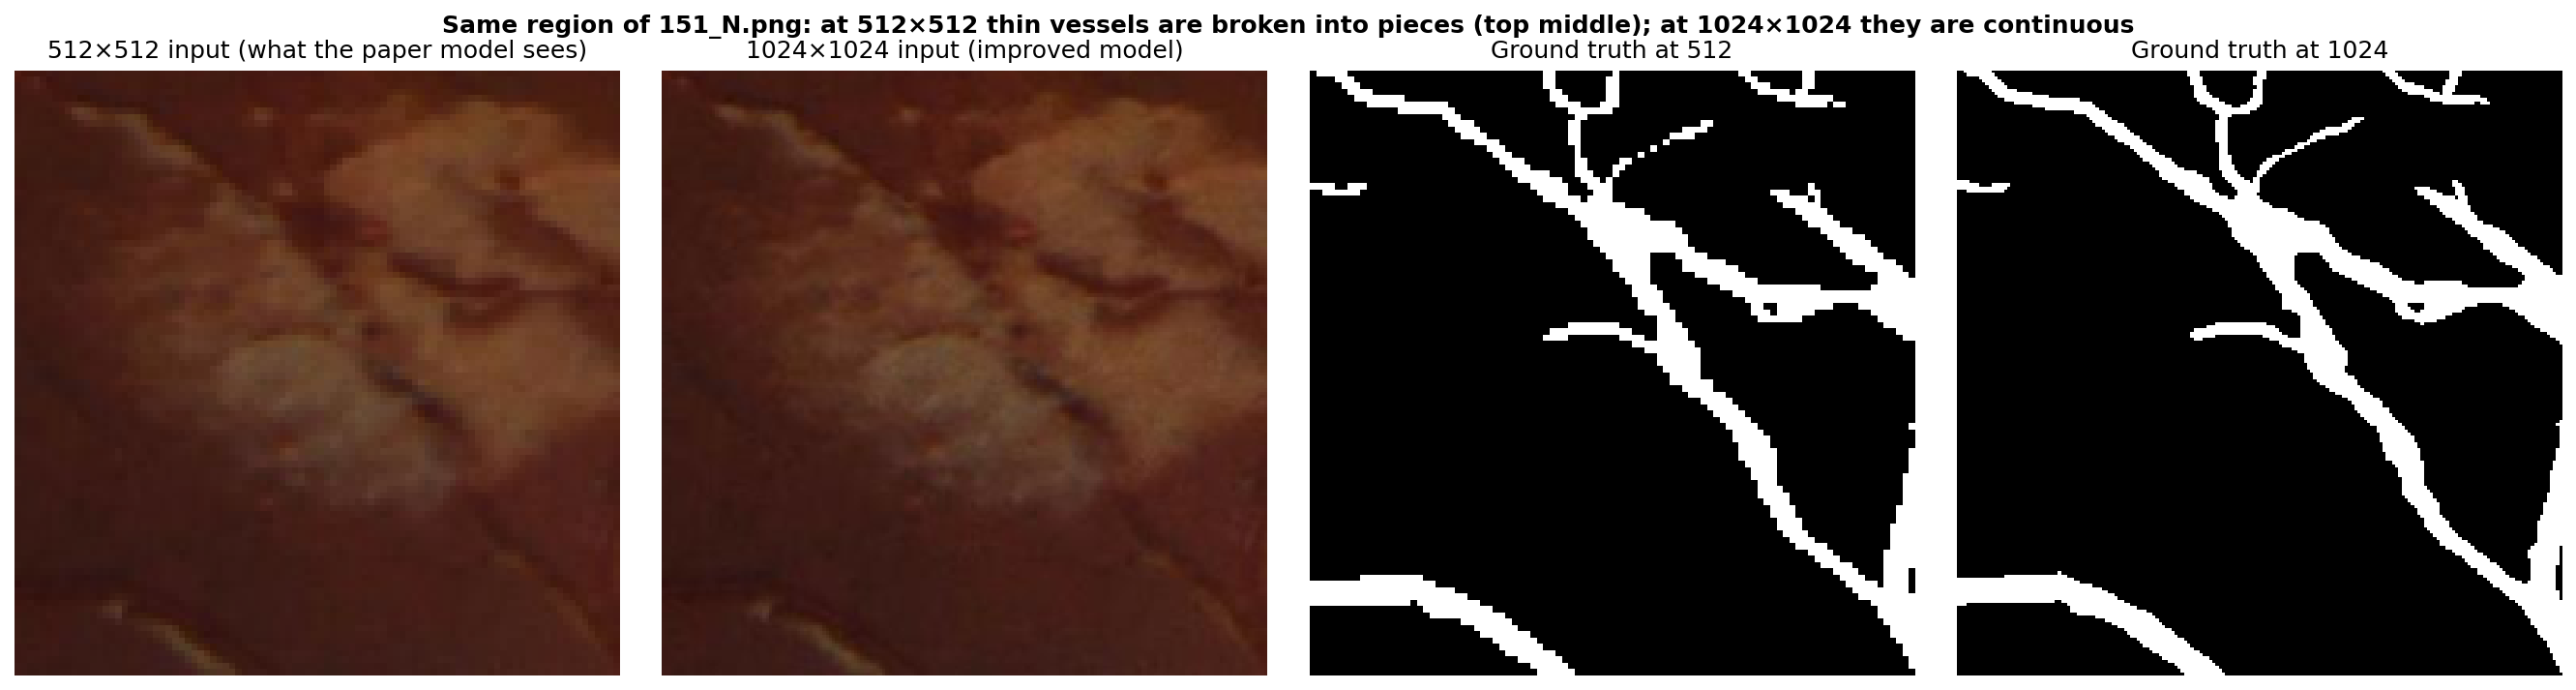

In [9]:
name = "151_N.png"
img512 = cv2.cvtColor(cv2.imread(f"data/FIVES_resized/test/images/{name}"), cv2.COLOR_BGR2RGB)
img1024 = cv2.cvtColor(cv2.imread(f"data/FIVES_1024/test/images/{name}"), cv2.COLOR_BGR2RGB)
gt512 = cv2.imread(f"data/FIVES_resized/test/masks/{name}", 0) > 128
gt1024 = cv2.imread(f"data/FIVES_1024/test/masks/{name}", 0) > 128
y, x, s = 330, 80, 96                                  # region in 512 coordinates
fig, ax = plt.subplots(1, 4, figsize=(18, 4.8))
ax[0].imshow(img512[y:y + s, x:x + s], interpolation="nearest"); ax[0].set_title("512×512 input (what the paper model sees)")
ax[1].imshow(img1024[2 * y:2 * (y + s), 2 * x:2 * (x + s)], interpolation="nearest"); ax[1].set_title("1024×1024 input (improved model)")
ax[2].imshow(gt512[y:y + s, x:x + s], cmap="gray", interpolation="nearest"); ax[2].set_title("Ground truth at 512")
ax[3].imshow(gt1024[2 * y:2 * (y + s), 2 * x:2 * (x + s)], cmap="gray", interpolation="nearest"); ax[3].set_title("Ground truth at 1024")
for a in ax: a.axis("off")
plt.suptitle(f"Same region of {name}: at 512×512 thin vessels are broken into pieces (top middle); at 1024×1024 they are continuous", fontweight="bold")
plt.tight_layout(); plt.show()

---
## 6. Improvement 4 — threshold chosen on the validation set (fixes W4)

**What:** the paper turns probabilities into vessel / background with a fixed threshold of 0.5. We choose the threshold that gives the best Dice on the **120 validation images only** (never the test set). We also tested **test-time augmentation (TTA)** — averaging predictions on 4 flipped copies — and let the validation set decide whether to use it.

**Finding:** the 1024 models are slightly conservative, so the validation set picks a lower threshold (0.44–0.48), which finds more vessels. TTA lowered Dice for most models (they segment flipped images slightly worse), so it is used only where validation shows it helps.

In [10]:
print(inspect.getsource(predict_with_flips))
print(inspect.getsource(selected_setting))

def predict_with_flips(model, item, device, batch):
    """
    Returns ((single, TTA) at 512 for the official metrics, (single, TTA) at model resolution).
    TTA = mean of the predictions on the 4 flipped copies, each flipped back before averaging.
    """
    evals, natives = zip(*[predict_item(model, item, device, batch, flip_axes=axes) for axes in FLIPS])
    return (evals[0], np.mean(evals, axis=0)), (natives[0], np.mean(natives, axis=0))

def selected_setting(post):
    """The prediction setting with the best VALIDATION Dice (the test set is never used for this choice)."""
    single, tta = post["val_dice_curve"]["single"], post["val_dice_curve"]["tta"]
    val = {"base": single["0.5"], "thr": max(single.values()), "tta": tta["0.5"], "tta_thr": max(tta.values())}
    return max(SETTINGS, key=lambda st: (round(val[st], 6), -SETTINGS.index(st)))  # ties -> simpler setting



 seed chosen setting  threshold
    0            thr       0.44
    1        tta_thr       0.44
    2            thr       0.48


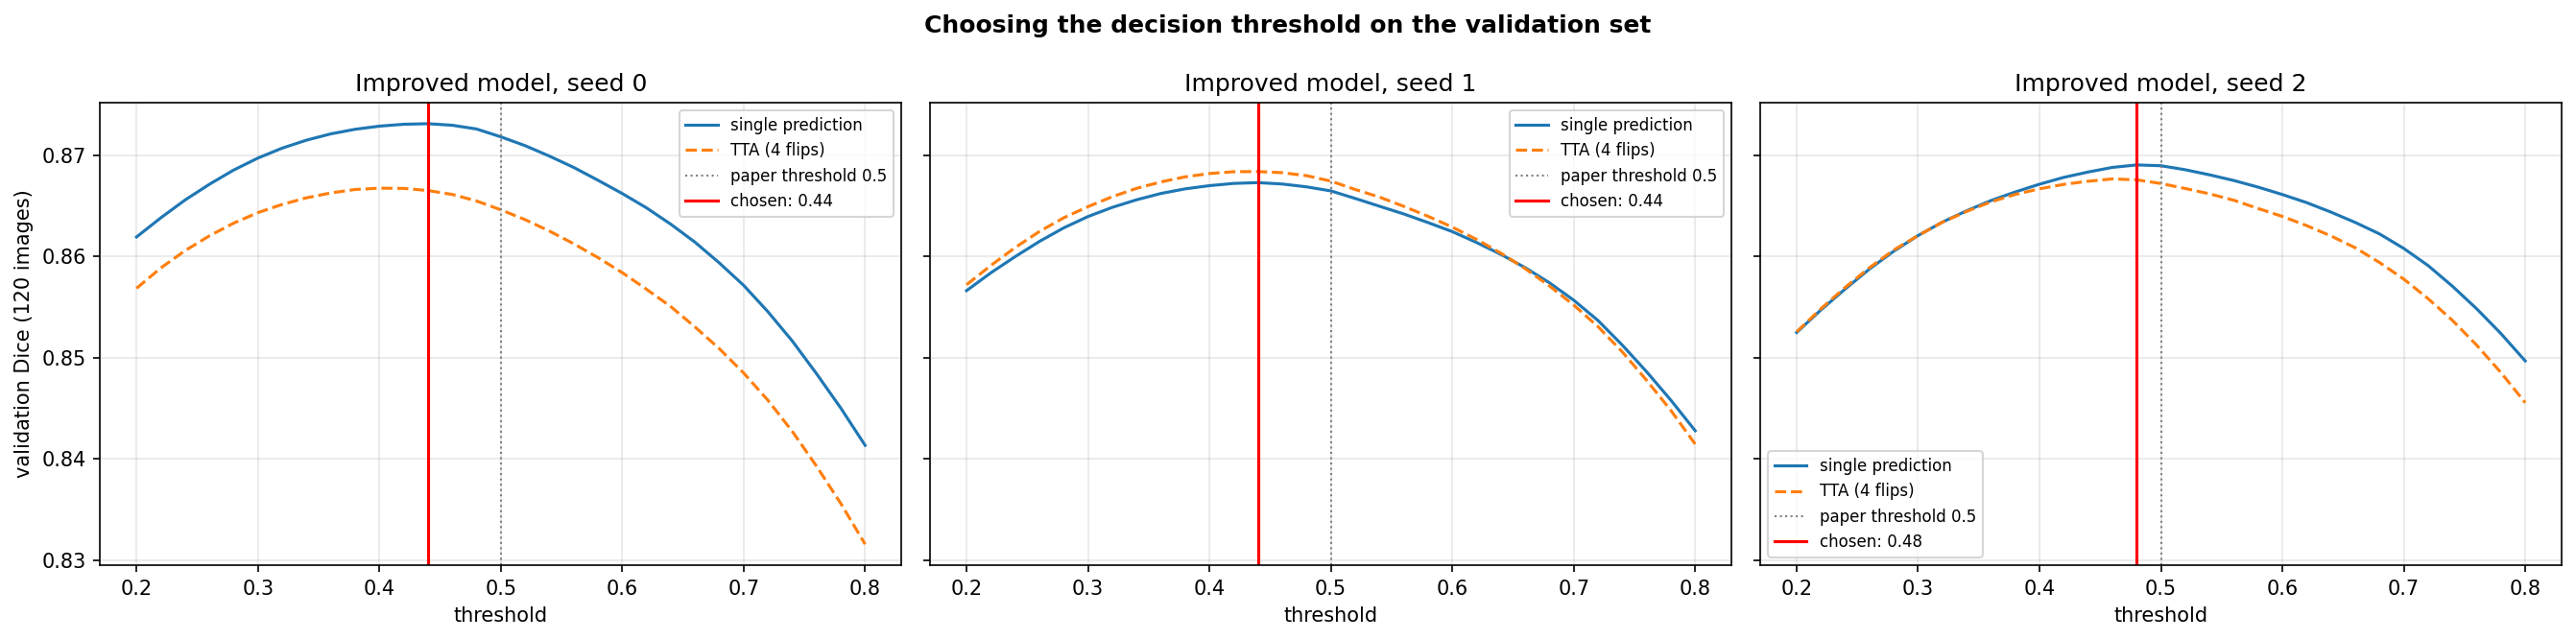

In [11]:
fig, ax = plt.subplots(1, 3, figsize=(18, 4.5), sharey=True)
rows = []
for a, seed in zip(ax, SEEDS):
    post = json.load(open(f"{RUNS}/{IMPROVED}_seed{seed}/post/summary.json"))
    for kind, style in [("single", "-"), ("tta", "--")]:
        curve = post["val_dice_curve"][kind]
        t = np.array([float(k) for k in curve]); d = np.array(list(curve.values()))
        a.plot(t, d, style, label="single prediction" if kind == "single" else "TTA (4 flips)")
    s, thr = improved_setting(seed)
    a.axvline(0.5, color="gray", lw=1, ls=":", label="paper threshold 0.5")
    a.axvline(thr, color="red", lw=1.5, label=f"chosen: {thr:.2f}")
    a.set_title(f"Improved model, seed {seed}"); a.set_xlabel("threshold"); a.legend(fontsize=8)
    rows.append({"seed": seed, "chosen setting": s, "threshold": thr})
ax[0].set_ylabel("validation Dice (120 images)")
plt.suptitle("Choosing the decision threshold on the validation set", fontweight="bold")
plt.tight_layout(); plt.show()
print(pd.DataFrame(rows).to_string(index=False))

---
## 7. Live test: paper model vs improved model on all 200 test images

Both trained models (seed 0) are run now on every test image. Besides the standard metrics we measure **thin-vessel recall**: the fraction of *thin* vessel pixels (vessel radius ≤ 1.5 px in the expert tracing) that the model finds. The live numbers are checked against the saved evaluation of the same models. *(Runs for ~10 minutes on the GPU.)*

In [12]:
s0, thr0 = improved_setting(0)
flips0 = [(), (1,), (0,), (0, 1)] if s0.startswith("tta") else [()]
print(f"Improved model, seed 0: setting chosen on validation = {s0}, threshold {thr0}")

live_rows, preds = [], {}
t0 = time.time()
for i, (ip, mp) in enumerate(test):
    fname = os.path.basename(ip)
    item512 = prepare_eval_item(ip, mp, 512)
    item1024 = prepare_eval_item(ip, mp, 1024)
    with torch.no_grad():
        p_prob, _ = predict_item(paper_model, item512, device, 36)
        i_prob = np.mean([predict_item(improved_model, item1024, device, 36, flip_axes=f)[0] for f in flips0], axis=0)
    gt, fov = item512["gt"].astype(np.float32), item512["fov"].astype(np.float32)
    thin = (gt > 0.5) & (distance_transform_edt(gt > 0.5) <= 1.5) & (fov > 0.5)
    for label, prob, thr in [(LABEL[PAPER], p_prob, 0.5), (LABEL[IMPROVED], i_prob, thr0)]:
        m = compute_fov_metrics(prob, gt, fov, threshold=thr)
        binary = (prob >= thr) & (fov > 0.5)
        m["clDice"] = compute_cldice(binary.astype(np.float32), gt, fov)
        m["thin_vessel_recall"] = (binary & thin).sum() / max(thin.sum(), 1)
        m.update(model=label, filename=fname, disease=DISEASE_NAMES[get_disease_code(fname)])
        live_rows.append(m)
    preds[fname] = ((p_prob >= 0.5) * fov).astype(np.uint8), ((i_prob >= thr0) * fov).astype(np.uint8)
    if (i + 1) % 50 == 0:
        print(f"  {i + 1}/200 images ({time.time() - t0:.0f}s)")
live = pd.DataFrame(live_rows)

cols = ["Accuracy", "Sensitivity", "Specificity", "Precision", "F1_Dice", "IoU", "AUC_ROC", "clDice", "thin_vessel_recall"]
table = live.groupby("model")[cols].mean().T[[LABEL[PAPER], LABEL[IMPROVED]]]
table["Change"] = table[LABEL[IMPROVED]] - table[LABEL[PAPER]]
print("\nLive results, seed 0 (200 test images):\n")
print(table.round(4).to_string())

chk_p = abs(live[live.model == LABEL[PAPER]].F1_Dice.mean() - paper_results(0).F1_Dice.mean())
chk_i = abs(live[live.model == LABEL[IMPROVED]].F1_Dice.mean() - improved_results(0).F1_Dice.mean())
print(f"\nConsistency check vs saved evaluation: |Dice difference| paper {chk_p:.1e}, improved {chk_i:.1e} "
      f"-> {'OK' if max(chk_p, chk_i) < 1e-3 else 'MISMATCH'}")

Improved model, seed 0: setting chosen on validation = thr, threshold 0.44
  50/200 images (117s)
  100/200 images (234s)
  150/200 images (367s)
  200/200 images (511s)

Live results, seed 0 (200 test images):

model               Paper model (CAR-UNet)  Improved model  Change
Accuracy                            0.9729          0.9744  0.0016
Sensitivity                         0.8411          0.8453  0.0042
Specificity                         0.9847          0.9856  0.0009
Precision                           0.8493          0.8579  0.0085
F1_Dice                             0.8411          0.8467  0.0055
IoU                                 0.7331          0.7423  0.0092
AUC_ROC                             0.9871          0.9875  0.0004
clDice                              0.8685          0.8754  0.0068
thin_vessel_recall                  0.7806          0.7883  0.0077

Consistency check vs saved evaluation: |Dice difference| paper 3.7e-06, improved 0.0e+00 -> OK


---
## 8. Main comparison over 3 training seeds

Each model was trained 3 times with different random seeds. The table shows mean ± standard deviation over the 3 runs (metrics in the paper's format first: Accuracy, Sensitivity, Specificity, AUC — then Dice, IoU, Precision, clDice).

            Paper model (CAR-UNet)   Improved model Change (points)
Accuracy           0.9728 ± 0.0007  0.9737 ± 0.0006           +0.09
Sensitivity        0.8310 ± 0.0126  0.8465 ± 0.0011           +1.55
Specificity        0.9855 ± 0.0018  0.9846 ± 0.0008           -0.09
AUC_ROC            0.9860 ± 0.0014  0.9878 ± 0.0003           +0.17
F1_Dice            0.8382 ± 0.0031  0.8436 ± 0.0027           +0.54
IoU                0.7295 ± 0.0043  0.7379 ± 0.0039           +0.83
Precision          0.8557 ± 0.0151  0.8516 ± 0.0054           -0.40
clDice             0.8626 ± 0.0057  0.8751 ± 0.0005           +1.25


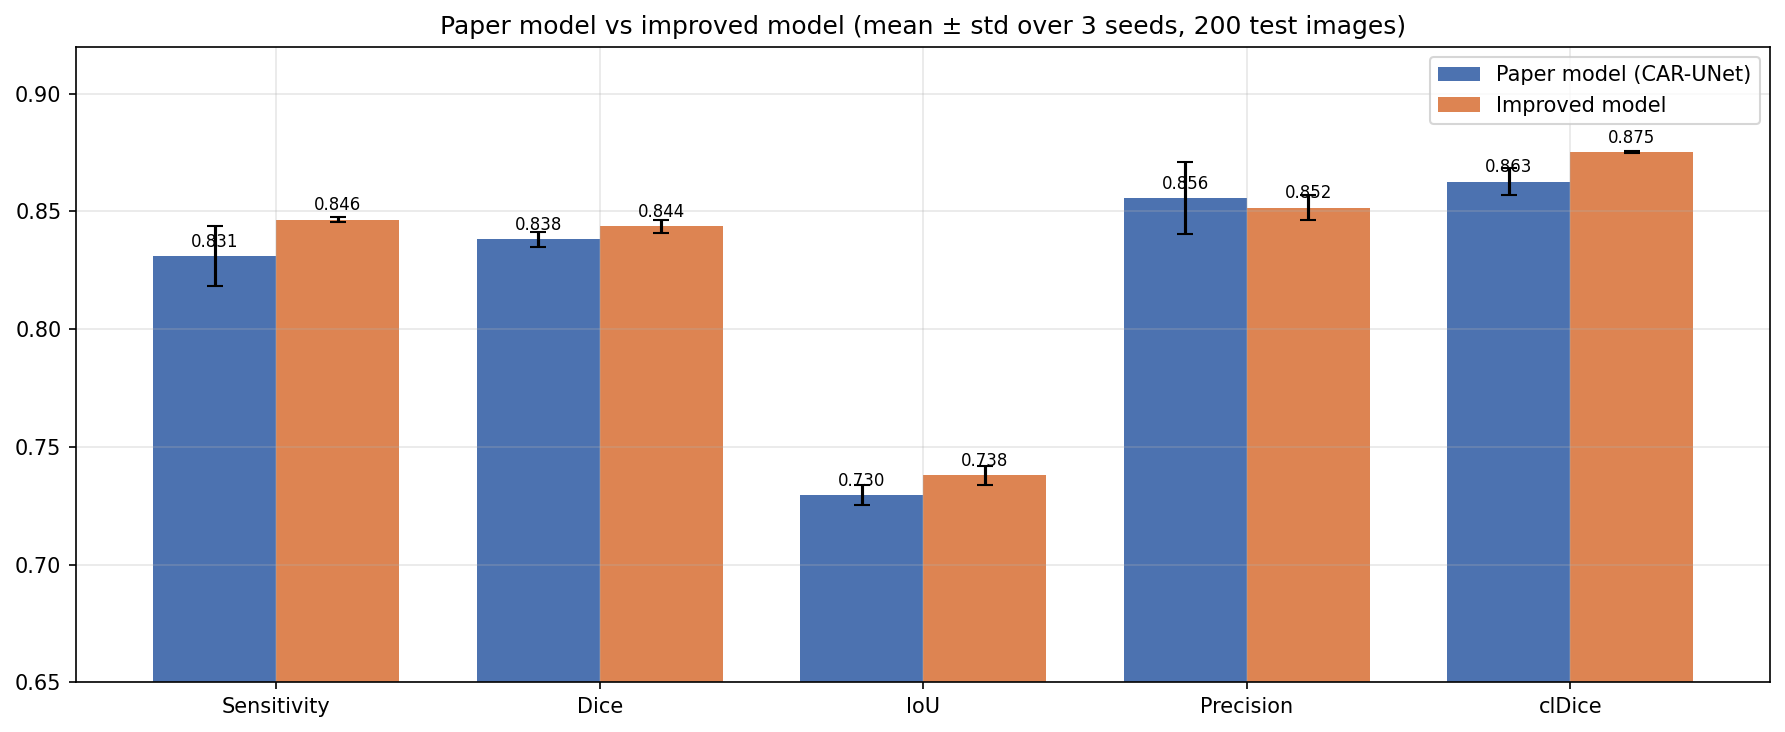

In [13]:
M = ["Accuracy", "Sensitivity", "Specificity", "AUC_ROC", "F1_Dice", "IoU", "Precision", "clDice"]
P = pd.DataFrame([paper_results(s)[M].mean() for s in SEEDS])
I = pd.DataFrame([improved_results(s)[M].mean() for s in SEEDS])
main = pd.DataFrame({
    LABEL[PAPER]: [f"{P[m].mean():.4f} ± {P[m].std():.4f}" for m in M],
    LABEL[IMPROVED]: [f"{I[m].mean():.4f} ± {I[m].std():.4f}" for m in M],
    "Change (points)": [f"{100 * (I[m].mean() - P[m].mean()):+.2f}" for m in M],
}, index=M)
print(main.to_string())

show = ["Sensitivity", "F1_Dice", "IoU", "Precision", "clDice"]
fig, ax = plt.subplots(figsize=(12, 5))
xs = np.arange(len(show))
for k, (label, df) in enumerate([(LABEL[PAPER], P), (LABEL[IMPROVED], I)]):
    ax.bar(xs + (k - 0.5) * 0.38, df[show].mean(), 0.38, yerr=df[show].std(), capsize=4, label=label, color=COLORS[label])
    for x_, v in zip(xs + (k - 0.5) * 0.38, df[show].mean()):
        ax.text(x_, v + 0.004, f"{v:.3f}", ha="center", fontsize=8)
ax.set_xticks(xs); ax.set_xticklabels(["Sensitivity", "Dice", "IoU", "Precision", "clDice"]); ax.set_ylim(0.65, 0.92)
ax.set_title("Paper model vs improved model (mean ± std over 3 seeds, 200 test images)"); ax.legend()
plt.tight_layout(); plt.show()

---
## 9. Is the improvement real? (statistical tests)

For every test image we compare the two models on the same image (paired test, scores averaged over the 3 seeds). The **Wilcoxon signed-rank test** checks whether the differences could be due to chance (p < 0.05 = statistically significant). The scatter plot shows each test image: points **above the diagonal** are images where the improved model is better.

     metric mean change improved better on p-value significant
    F1_Dice     +0.0054   140 / 200 images 4.8e-10         yes
Sensitivity     +0.0155   159 / 200 images 7.4e-19         yes
  Precision     -0.0040    68 / 200 images 9.6e-08         yes
    AUC_ROC     +0.0017   168 / 200 images 1.4e-21         yes
     clDice     +0.0125   175 / 200 images 5.3e-25         yes

Per training seed:
 seed  paper Dice  improved Dice  paper clDice  improved clDice  Dice gain  clDice gain
    0      0.8411         0.8467        0.8685           0.8754     0.0055       0.0068
    1      0.8349         0.8426        0.8571           0.8754     0.0078       0.0182
    2      0.8385         0.8415        0.8620           0.8745     0.0030       0.0124
(Two very low-quality images with Dice < 0.1 for both models lie outside the plotted range.)


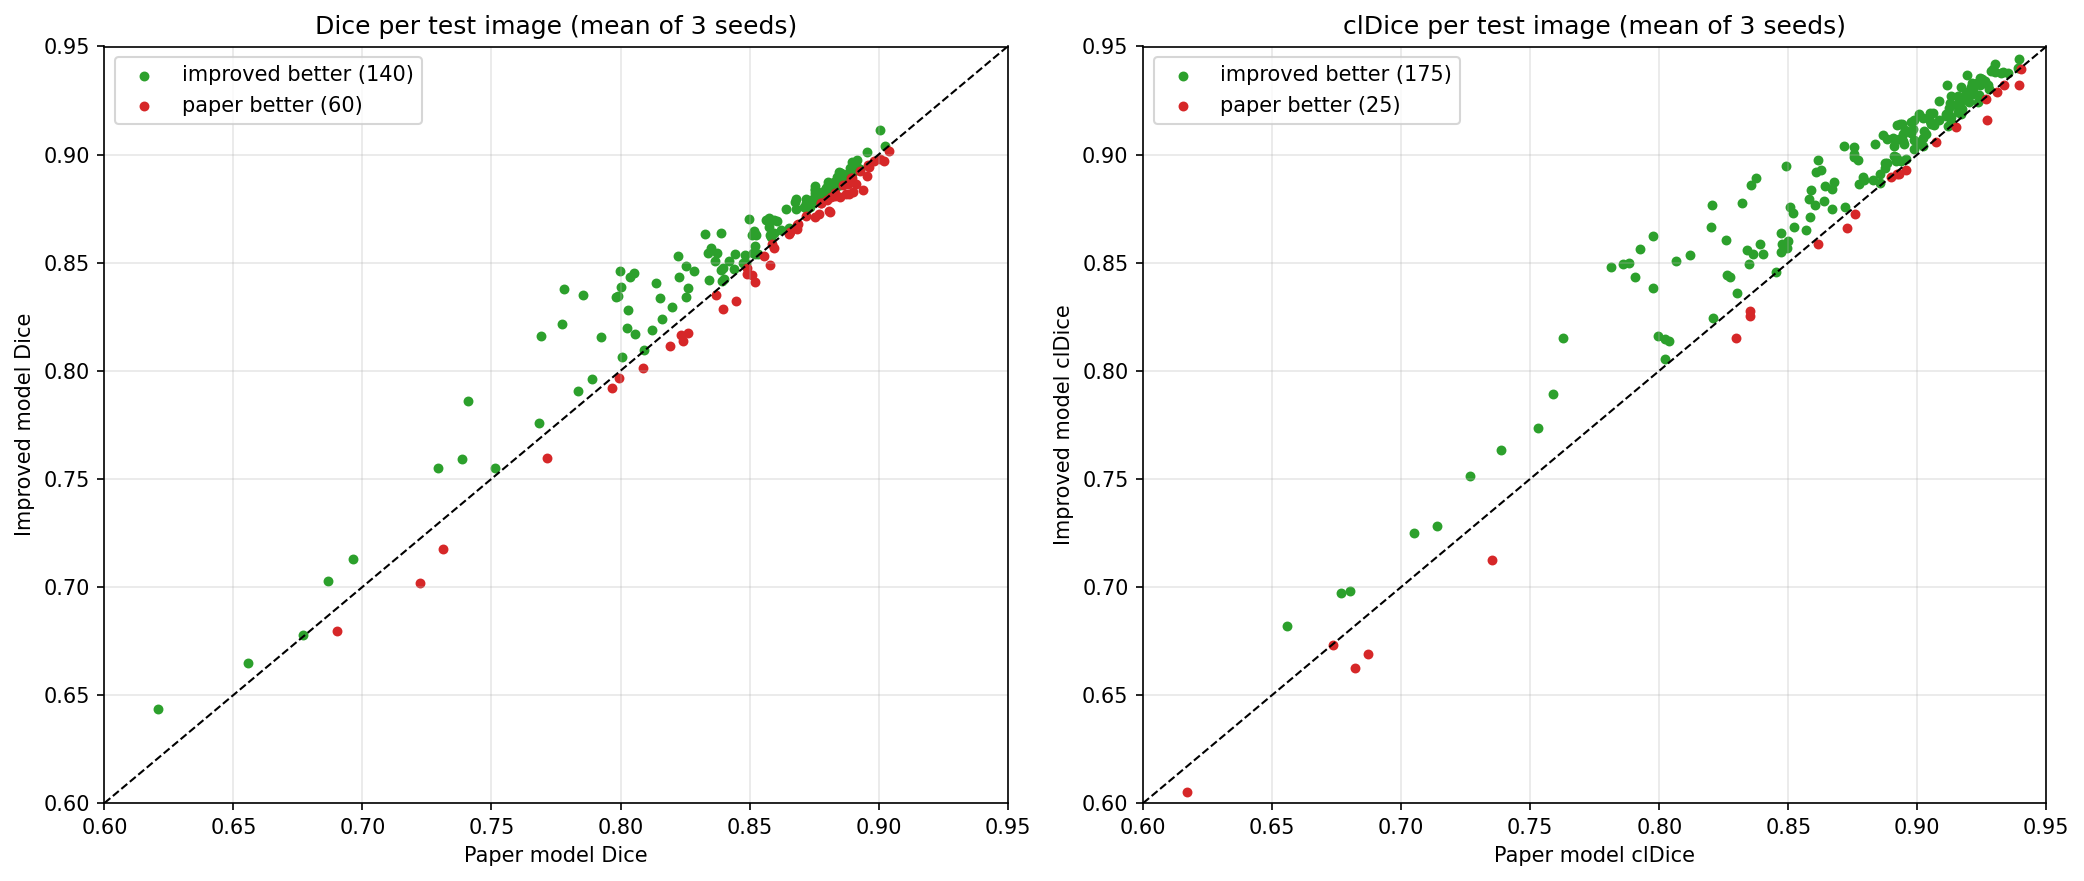

In [14]:
test_rows = []
for m in ["F1_Dice", "Sensitivity", "Precision", "AUC_ROC", "clDice"]:
    a = pd.concat([paper_results(s)[m] for s in SEEDS], axis=1).mean(1)
    b = pd.concat([improved_results(s)[m] for s in SEEDS], axis=1).loc[a.index].mean(1)
    test_rows.append({"metric": m, "mean change": f"{b.mean() - a.mean():+.4f}", "improved better on": f"{int((b > a).sum())} / {len(a)} images",
                      "p-value": f"{wilcoxon(b, a).pvalue:.1e}", "significant": "yes" if wilcoxon(b, a).pvalue < 0.05 else "no"})
print(pd.DataFrame(test_rows).to_string(index=False))

seed_rows = [{"seed": s, "paper Dice": paper_results(s).F1_Dice.mean(), "improved Dice": improved_results(s).F1_Dice.mean(),
              "paper clDice": paper_results(s).clDice.mean(), "improved clDice": improved_results(s).clDice.mean()} for s in SEEDS]
sd = pd.DataFrame(seed_rows); sd["Dice gain"] = sd["improved Dice"] - sd["paper Dice"]; sd["clDice gain"] = sd["improved clDice"] - sd["paper clDice"]
print("\nPer training seed:\n" + sd.round(4).to_string(index=False))

pa = pd.concat([paper_results(s)["F1_Dice"] for s in SEEDS], axis=1).mean(1)
ia = pd.concat([improved_results(s)["F1_Dice"] for s in SEEDS], axis=1).loc[pa.index].mean(1)
pc = pd.concat([paper_results(s)["clDice"] for s in SEEDS], axis=1).mean(1)
ic = pd.concat([improved_results(s)["clDice"] for s in SEEDS], axis=1).loc[pc.index].mean(1)
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
for a, (x_, y_, name) in zip(ax, [(pa, ia, "Dice"), (pc, ic, "clDice")]):
    better = y_ > x_
    a.scatter(x_[better], y_[better], s=14, c="#2ca02c", label=f"improved better ({better.sum()})")
    a.scatter(x_[~better], y_[~better], s=14, c="#d62728", label=f"paper better ({(~better).sum()})")
    lo = max(0.6, min(x_.min(), y_.min()) - 0.01)
    a.plot([lo, 1], [lo, 1], "k--", lw=1); a.set_xlim(lo, 0.95); a.set_ylim(lo, 0.95)
    a.set_xlabel(f"Paper model {name}"); a.set_ylabel(f"Improved model {name}"); a.set_title(f"{name} per test image (mean of 3 seeds)"); a.legend()
plt.tight_layout(); plt.show()
print("(Two very low-quality images with Dice < 0.1 for both models lie outside the plotted range.)")

---
## 10. Ablation — what each improvement contributes

The improvements are added one at a time to the paper model (each step trained with 3 seeds). This shows the role of each one: dual attention improves Dice and precision, clDice improves connectivity and sensitivity, higher resolution improves overall accuracy and thin vessels, and the tuned threshold converts the higher resolution's precision into more vessels found.

                              step         F1_Dice     Sensitivity       Precision          clDice
            Paper model (CAR-UNet) 0.8382 ± 0.0031 0.8310 ± 0.0126 0.8557 ± 0.0151 0.8626 ± 0.0057
                  + Dual attention 0.8408 ± 0.0021 0.8308 ± 0.0005 0.8620 ± 0.0049 0.8631 ± 0.0020
                     + clDice loss 0.8382 ± 0.0050 0.8432 ± 0.0071 0.8430 ± 0.0048 0.8718 ± 0.0041
                 + 1024 resolution 0.8421 ± 0.0028 0.8326 ± 0.0069 0.8632 ± 0.0104 0.8742 ± 0.0011
+ tuned threshold = Improved model 0.8436 ± 0.0027 0.8465 ± 0.0011 0.8516 ± 0.0054 0.8751 ± 0.0005


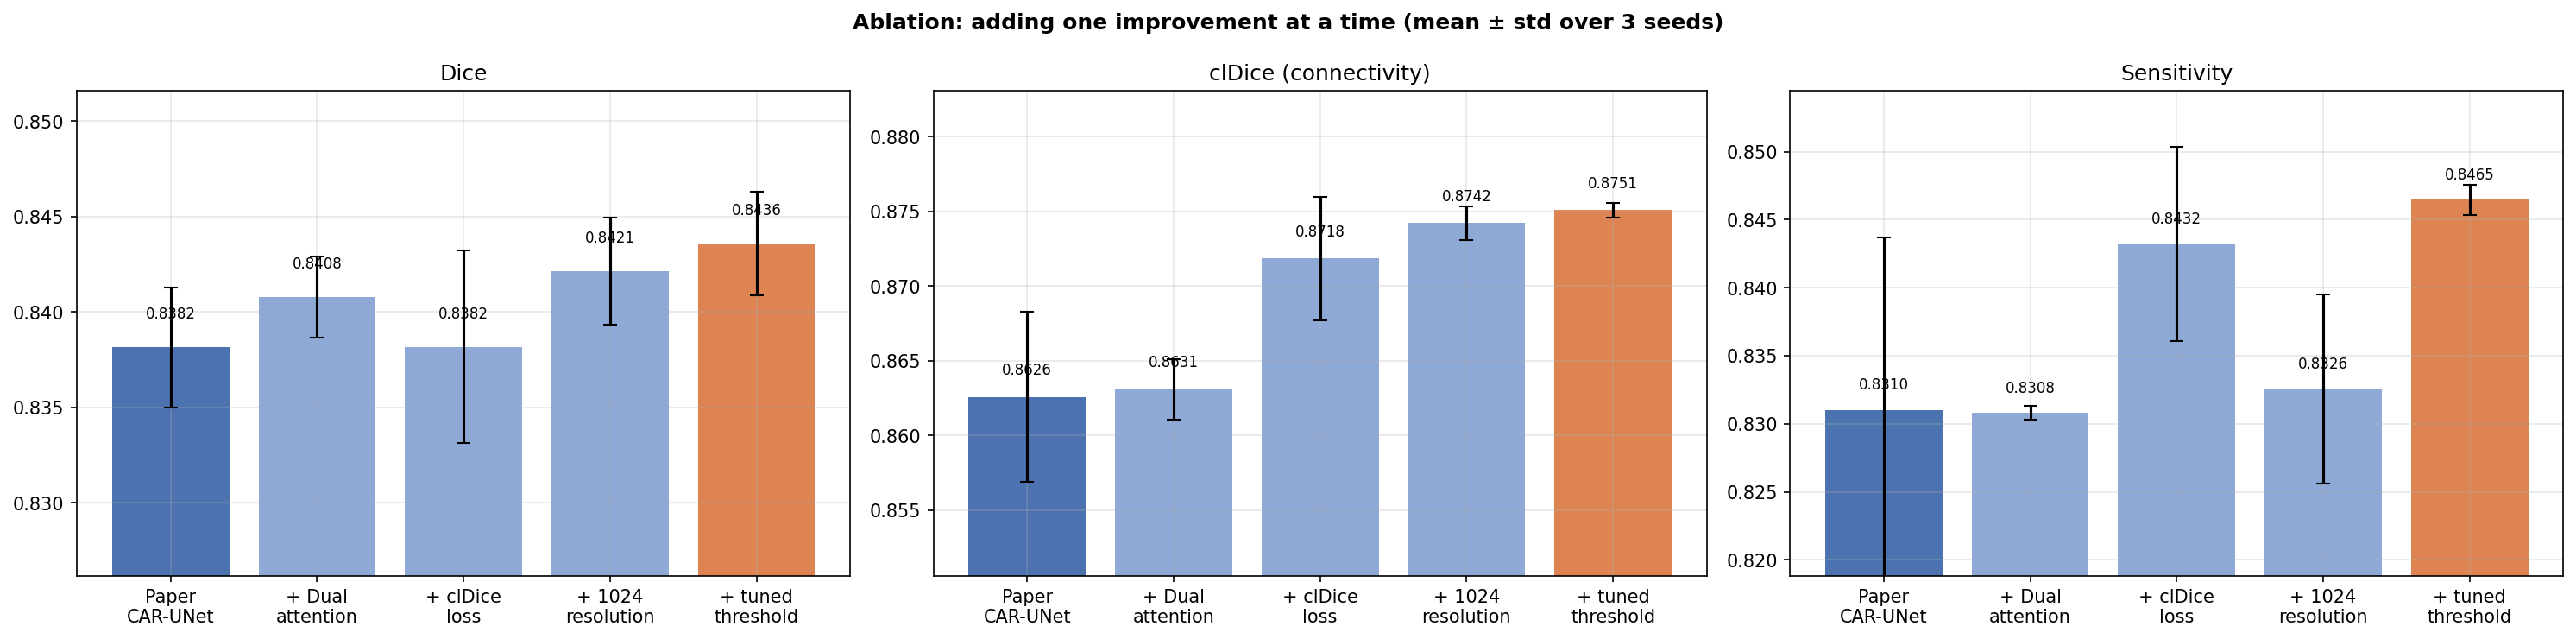

In [15]:
steps = [("Paper model (CAR-UNet)", lambda s: per_image("car_unet", s)),
         ("+ Dual attention", lambda s: per_image("car_unet_da", s)),
         ("+ clDice loss", lambda s: per_image("car_unet_da_cldice", s)),
         ("+ 1024 resolution", lambda s: per_image(IMPROVED, s)),
         ("+ tuned threshold = Improved model", improved_results)]
abl_rows, abl_vals = [], {}
for name, f in steps:
    d = pd.DataFrame([f(s)[["F1_Dice", "Sensitivity", "Precision", "clDice"]].mean() for s in SEEDS])
    abl_vals[name] = d
    abl_rows.append({"step": name, **{m: f"{d[m].mean():.4f} ± {d[m].std():.4f}" for m in d}})
print(pd.DataFrame(abl_rows).to_string(index=False))

fig, ax = plt.subplots(1, 3, figsize=(20, 5))
names = list(abl_vals)
short = ["Paper\nCAR-UNet", "+ Dual\nattention", "+ clDice\nloss", "+ 1024\nresolution", "+ tuned\nthreshold"]
for a, m, title in zip(ax, ["F1_Dice", "clDice", "Sensitivity"], ["Dice", "clDice (connectivity)", "Sensitivity"]):
    means = [abl_vals[n][m].mean() for n in names]; stds = [abl_vals[n][m].std() for n in names]
    a.bar(range(len(names)), means, yerr=stds, capsize=4, color=["#4C72B0"] + ["#8FA9D6"] * 3 + ["#DD8452"])
    for k, v in enumerate(means):
        a.text(k, v + 0.0015, f"{v:.4f}", ha="center", fontsize=8)
    a.set_xticks(range(len(names))); a.set_xticklabels(short); a.set_ylim(min(means) - 0.012, max(means) + 0.008); a.set_title(title)
plt.suptitle("Ablation: adding one improvement at a time (mean ± std over 3 seeds)", fontweight="bold")
plt.tight_layout(); plt.show()

---
## 11. Results per disease group

          paper F1_Dice  improved F1_Dice  change F1_Dice  paper clDice  improved clDice  change clDice  paper Sensitivity  improved Sensitivity  change Sensitivity
disease                                                                                                                                                             
AMD              0.8643            0.8671          0.0028        0.8884           0.8978         0.0094             0.8710                0.8831              0.0121
DR               0.8562            0.8585          0.0022        0.8807           0.8895         0.0088             0.8544                0.8674              0.0130
Glaucoma         0.7958            0.7947         -0.0011        0.8178           0.8227         0.0049             0.7764                0.7760             -0.0004
Normal           0.8363            0.8541          0.0178        0.8635           0.8904         0.0269             0.8222                0.8594              0.0371


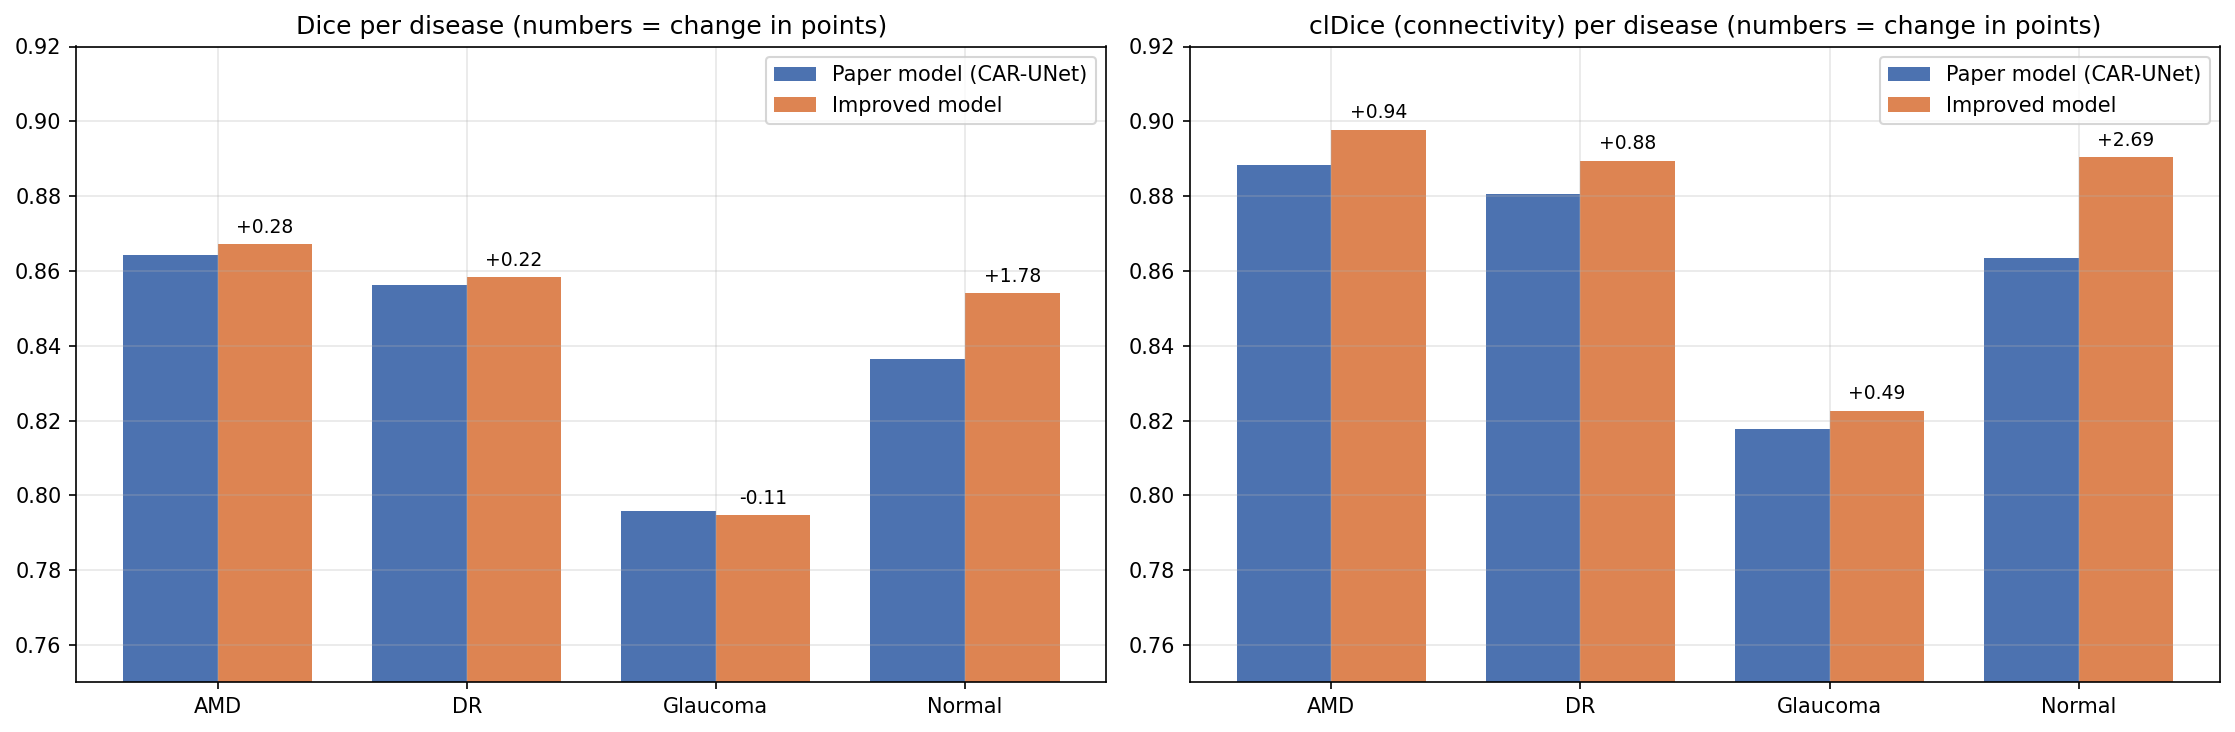

In [16]:
dis_rows = []
for d in ["AMD", "DR", "Glaucoma", "Normal"]:
    row = {"disease": d}
    for m in ["F1_Dice", "clDice", "Sensitivity"]:
        p = np.mean([paper_results(s).query("disease == @d")[m].mean() for s in SEEDS])
        q = np.mean([improved_results(s).query("disease == @d")[m].mean() for s in SEEDS])
        row.update({f"paper {m}": p, f"improved {m}": q, f"change {m}": q - p})
    dis_rows.append(row)
dis = pd.DataFrame(dis_rows).set_index("disease")
print(dis.round(4).to_string())

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
xs = np.arange(4)
for a, m, title in zip(ax, ["F1_Dice", "clDice"], ["Dice per disease", "clDice (connectivity) per disease"]):
    a.bar(xs - 0.19, dis[f"paper {m}"], 0.38, label=LABEL[PAPER], color=COLORS[LABEL[PAPER]])
    a.bar(xs + 0.19, dis[f"improved {m}"], 0.38, label=LABEL[IMPROVED], color=COLORS[LABEL[IMPROVED]])
    for k in range(4):
        a.text(xs[k] + 0.19, dis[f"improved {m}"].iloc[k] + 0.003, f"{100 * dis[f'change {m}'].iloc[k]:+.2f}", ha="center", fontsize=9)
    a.set_xticks(xs); a.set_xticklabels(dis.index); a.set_ylim(0.75, 0.92); a.set_title(title + " (numbers = change in points)"); a.legend()
plt.tight_layout(); plt.show()

---
## 12. Thin vessels — the main goal of the improvements

Two measurements focus on thin vessels:
1. **Thin-vessel recall** (live, seed 0): fraction of thin vessel pixels found.
2. **Scores against the 1024×1024 ground truth**, where thin vessels are much better represented than at 512×512 (paper-model predictions are upsampled; 3 seeds).

Thin-vessel recall (seed 0): paper 0.7806 -> improved 0.7883 (+0.77 points)
Improved model finds more thin-vessel pixels on 139 / 200 images (p = 2.7e-07)

Scored against the 1024×1024 ground truth (mean ± std over 3 seeds):
  Paper model (CAR-UNet)           Dice 0.8572 ± 0.0125 | clDice 0.8791
  Same improved model at 512×512   Dice 0.8599 ± 0.0030 | clDice 0.8895
  Improved model                   Dice 0.8796 ± 0.0015 | clDice 0.8972


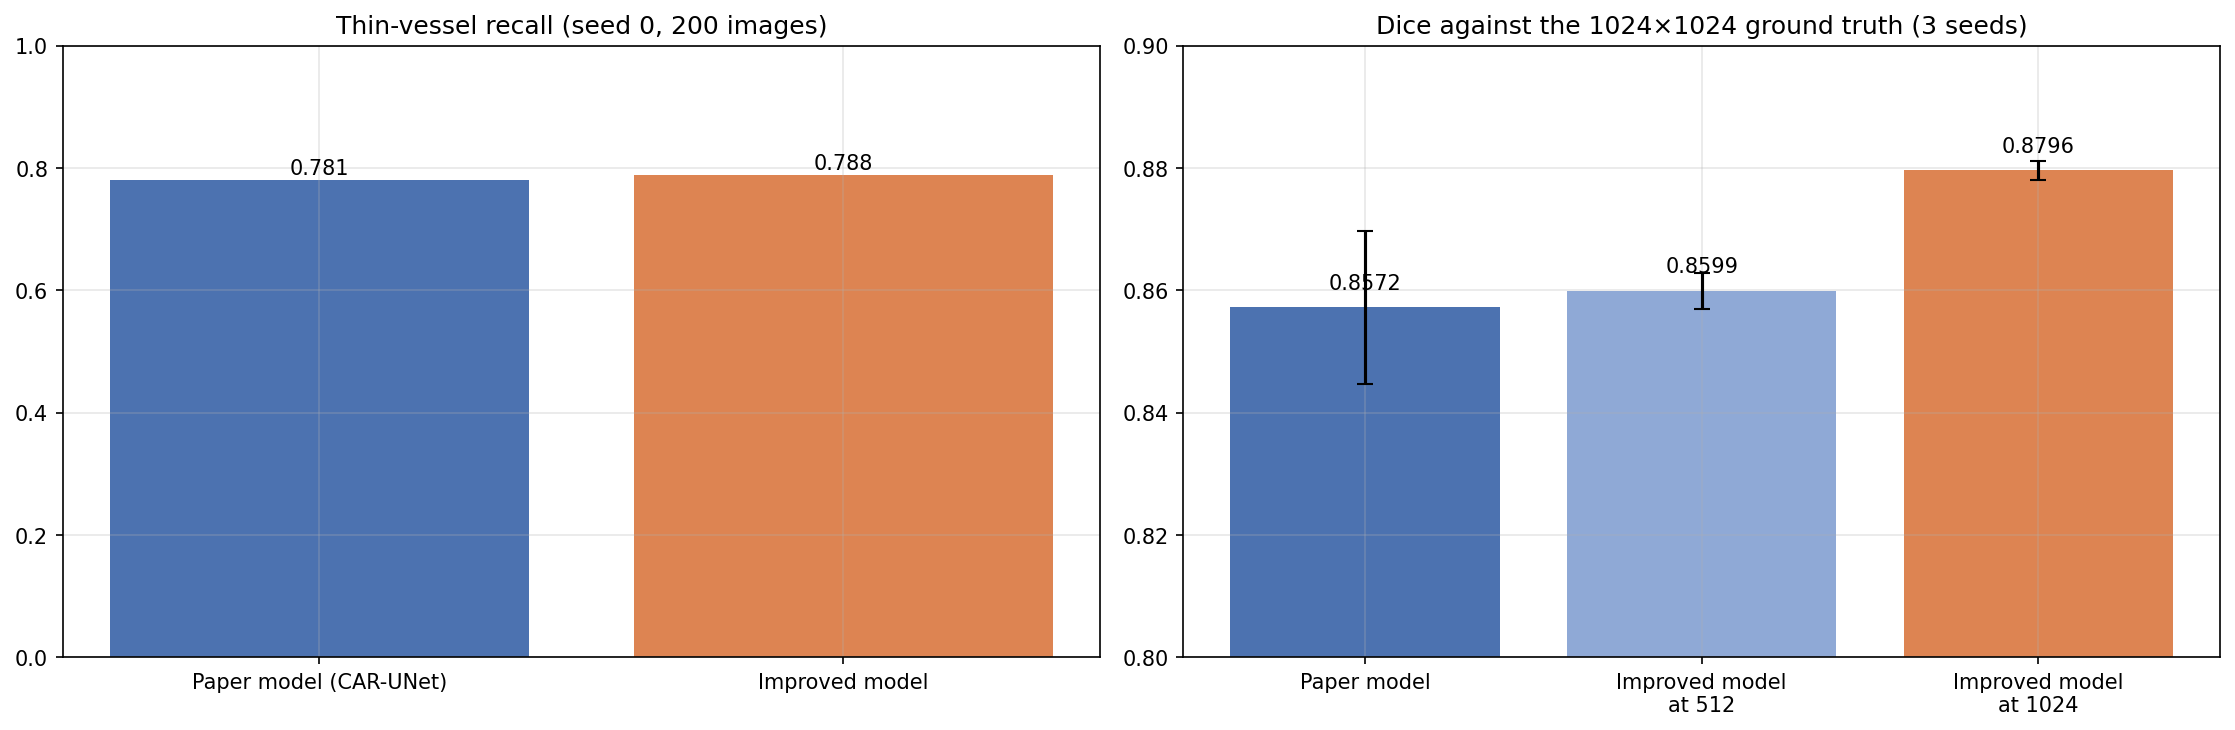

In [17]:
tv = live.groupby("model")["thin_vessel_recall"].mean()
print(f"Thin-vessel recall (seed 0): paper {tv[LABEL[PAPER]]:.4f} -> improved {tv[LABEL[IMPROVED]]:.4f} "
      f"({100 * (tv[LABEL[IMPROVED]] - tv[LABEL[PAPER]]):+.2f} points)")
a = live[live.model == LABEL[PAPER]].set_index("filename")["thin_vessel_recall"]
b = live[live.model == LABEL[IMPROVED]].set_index("filename")["thin_vessel_recall"].loc[a.index]
print(f"Improved model finds more thin-vessel pixels on {(b > a).sum()} / 200 images (p = {wilcoxon(b, a).pvalue:.1e})")

hi = {}
for label, key in [(LABEL[PAPER], PAPER), ("Same improved model at 512×512", "car_unet_da_cldice"), (LABEL[IMPROVED], IMPROVED)]:
    o = [json.load(open(f"{RUNS}/{key}_seed{s}/post/summary.json"))["settings"]["base"]["overall"] for s in SEEDS]
    hi[label] = {"Dice": [x["hires_F1_Dice"] for x in o], "clDice": [x["hires_clDice"] for x in o]}
print("\nScored against the 1024×1024 ground truth (mean ± std over 3 seeds):")
for label, v in hi.items():
    print(f"  {label:32s} Dice {np.mean(v['Dice']):.4f} ± {np.std(v['Dice'], ddof=1):.4f} | clDice {np.mean(v['clDice']):.4f}")

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].bar([LABEL[PAPER], LABEL[IMPROVED]], [tv[LABEL[PAPER]], tv[LABEL[IMPROVED]]], color=[COLORS[LABEL[PAPER]], COLORS[LABEL[IMPROVED]]])
ax[0].set_title("Thin-vessel recall (seed 0, 200 images)"); ax[0].set_ylim(0, 1)
for k, v in enumerate([tv[LABEL[PAPER]], tv[LABEL[IMPROVED]]]):
    ax[0].text(k, v + 0.01, f"{v:.3f}", ha="center")
labels = list(hi)
ax[1].bar(range(3), [np.mean(hi[l]["Dice"]) for l in labels], yerr=[np.std(hi[l]["Dice"], ddof=1) for l in labels], capsize=4,
          color=[COLORS[LABEL[PAPER]], "#8FA9D6", COLORS[LABEL[IMPROVED]]])
ax[1].set_xticks(range(3)); ax[1].set_xticklabels(["Paper model", "Improved model\nat 512", "Improved model\nat 1024"]); ax[1].set_ylim(0.8, 0.9)
for k, l in enumerate(labels):
    ax[1].text(k, np.mean(hi[l]["Dice"]) + 0.003, f"{np.mean(hi[l]['Dice']):.4f}", ha="center")
ax[1].set_title("Dice against the 1024×1024 ground truth (3 seeds)")
plt.tight_layout(); plt.show()

---
## 13. Visual comparison

One typical test image per disease (the image with the **median** paper-model Dice in its group — not hand-picked). Error maps: **green** = correctly found vessel, **red** = false vessel, **blue** = missed vessel. The second figure zooms into the 128×128 region with the most thin vessels (chosen automatically from the expert tracing).

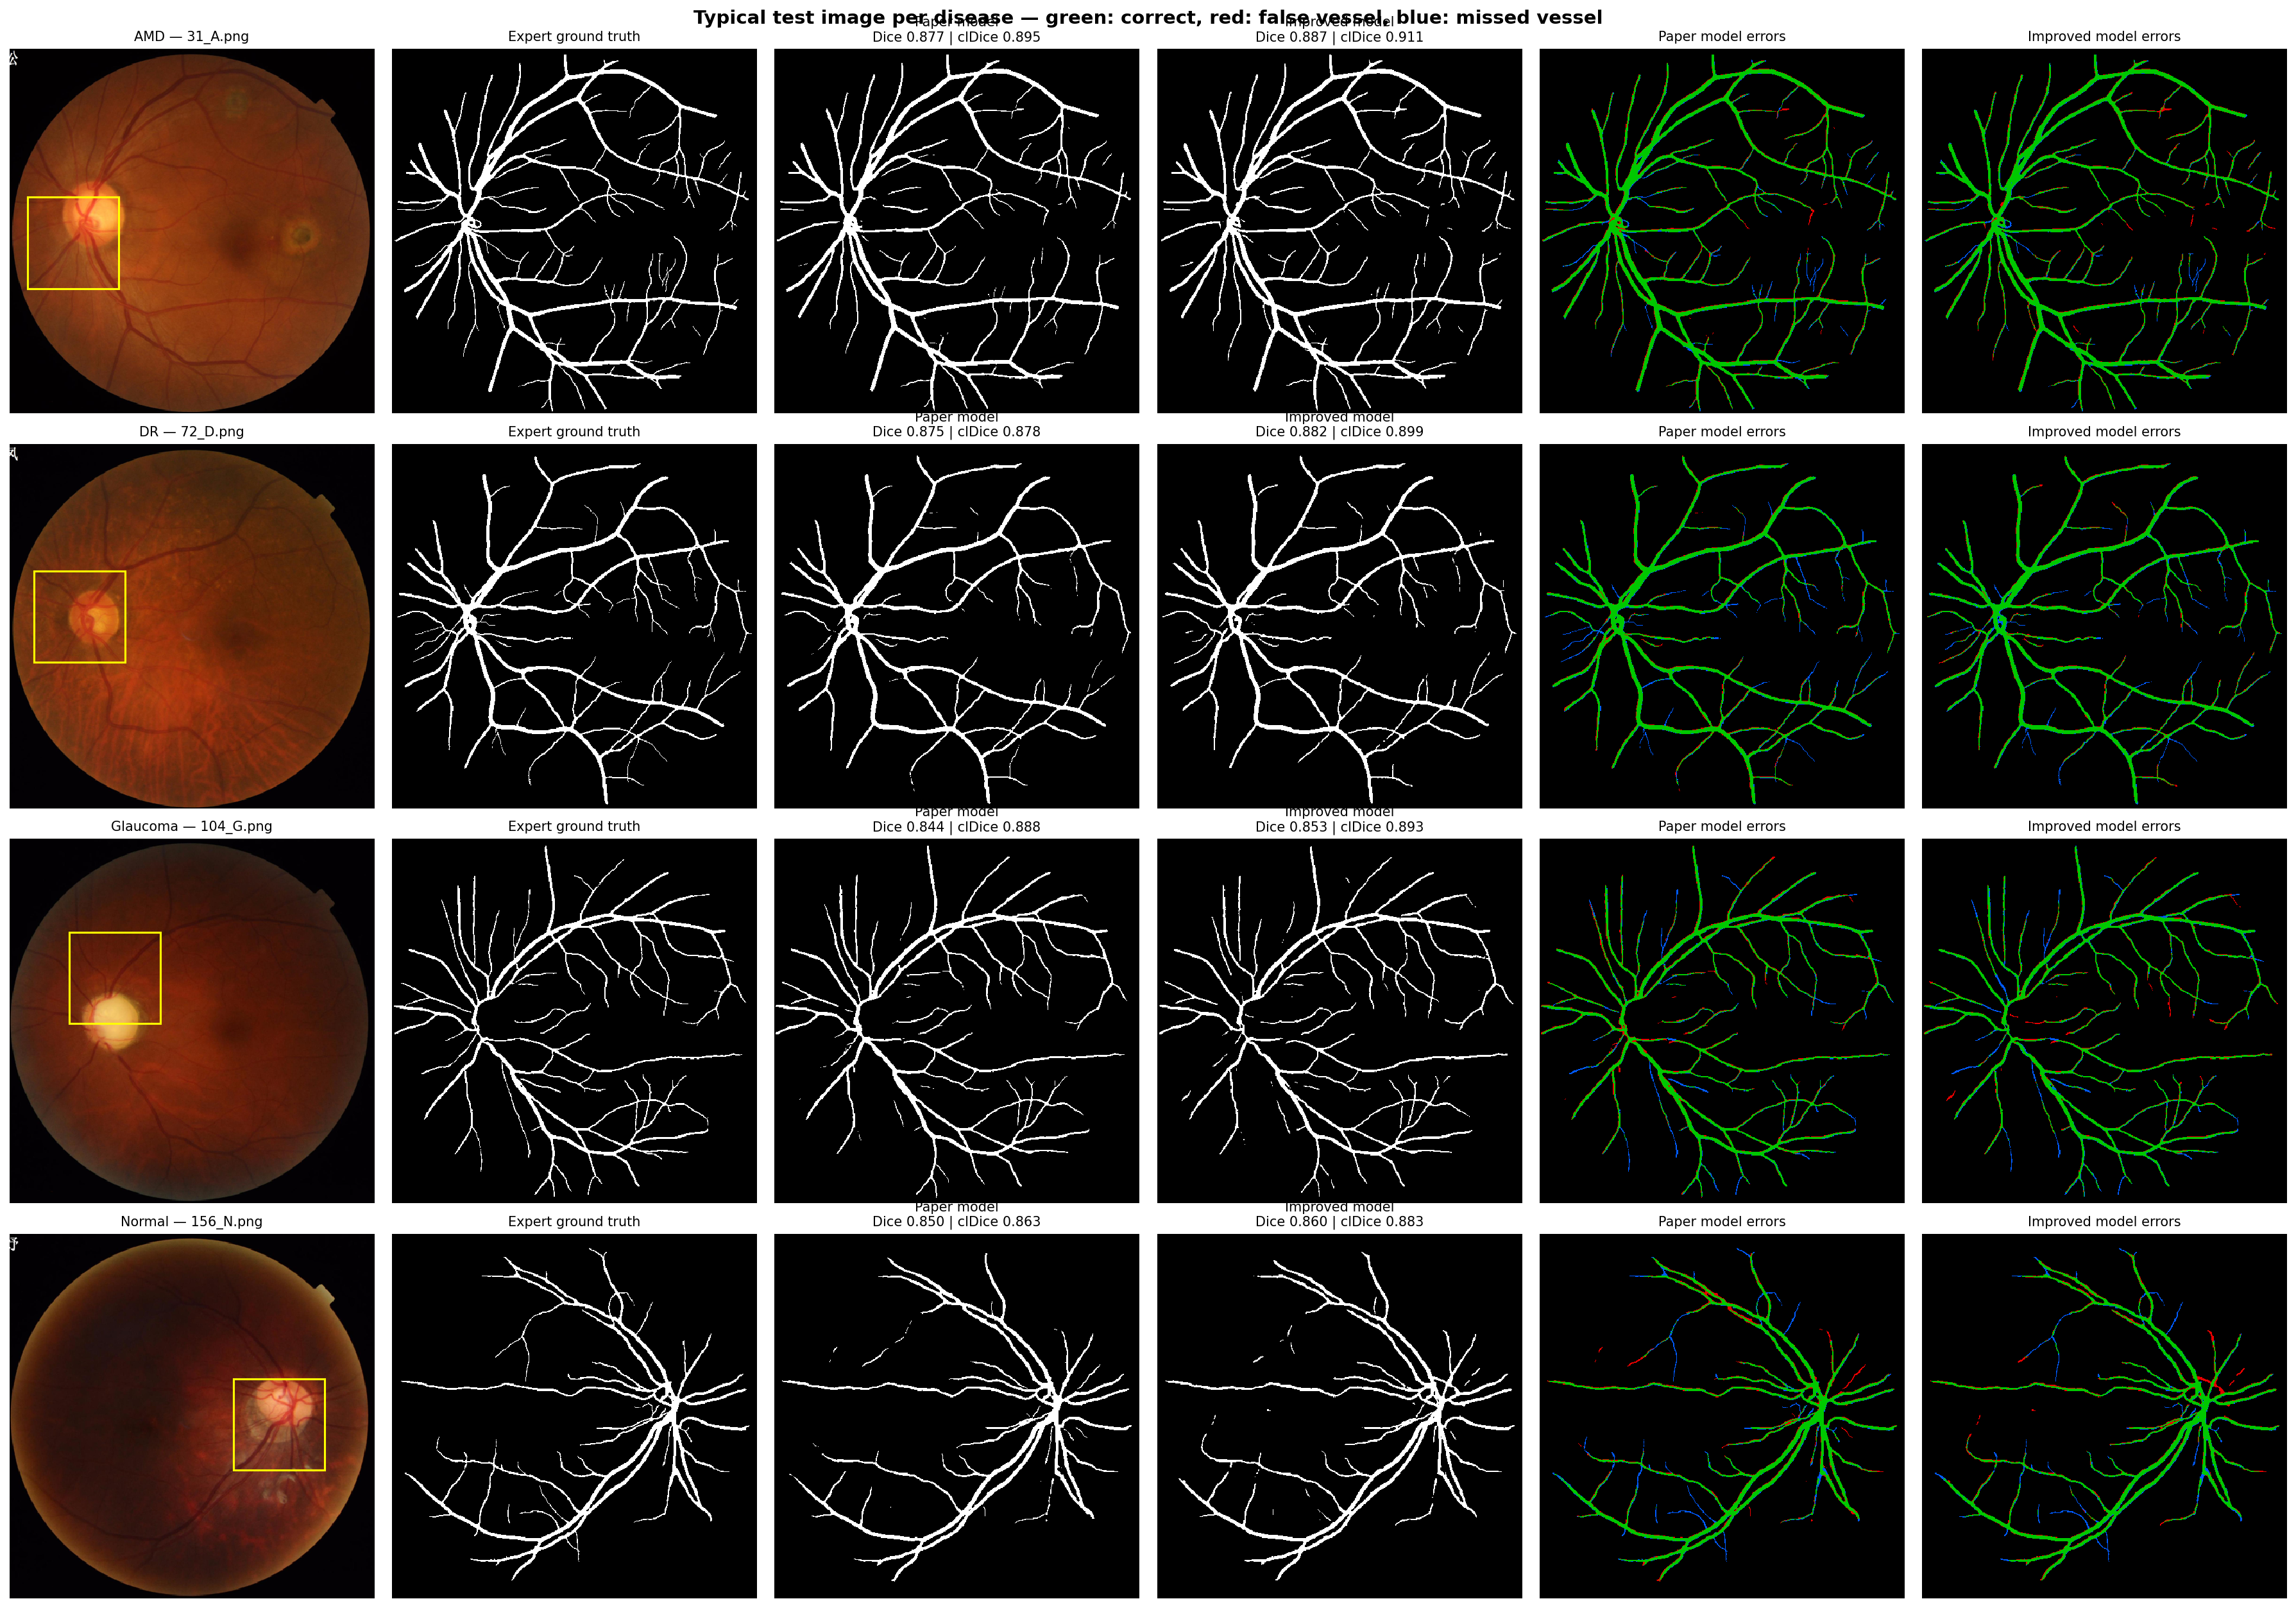

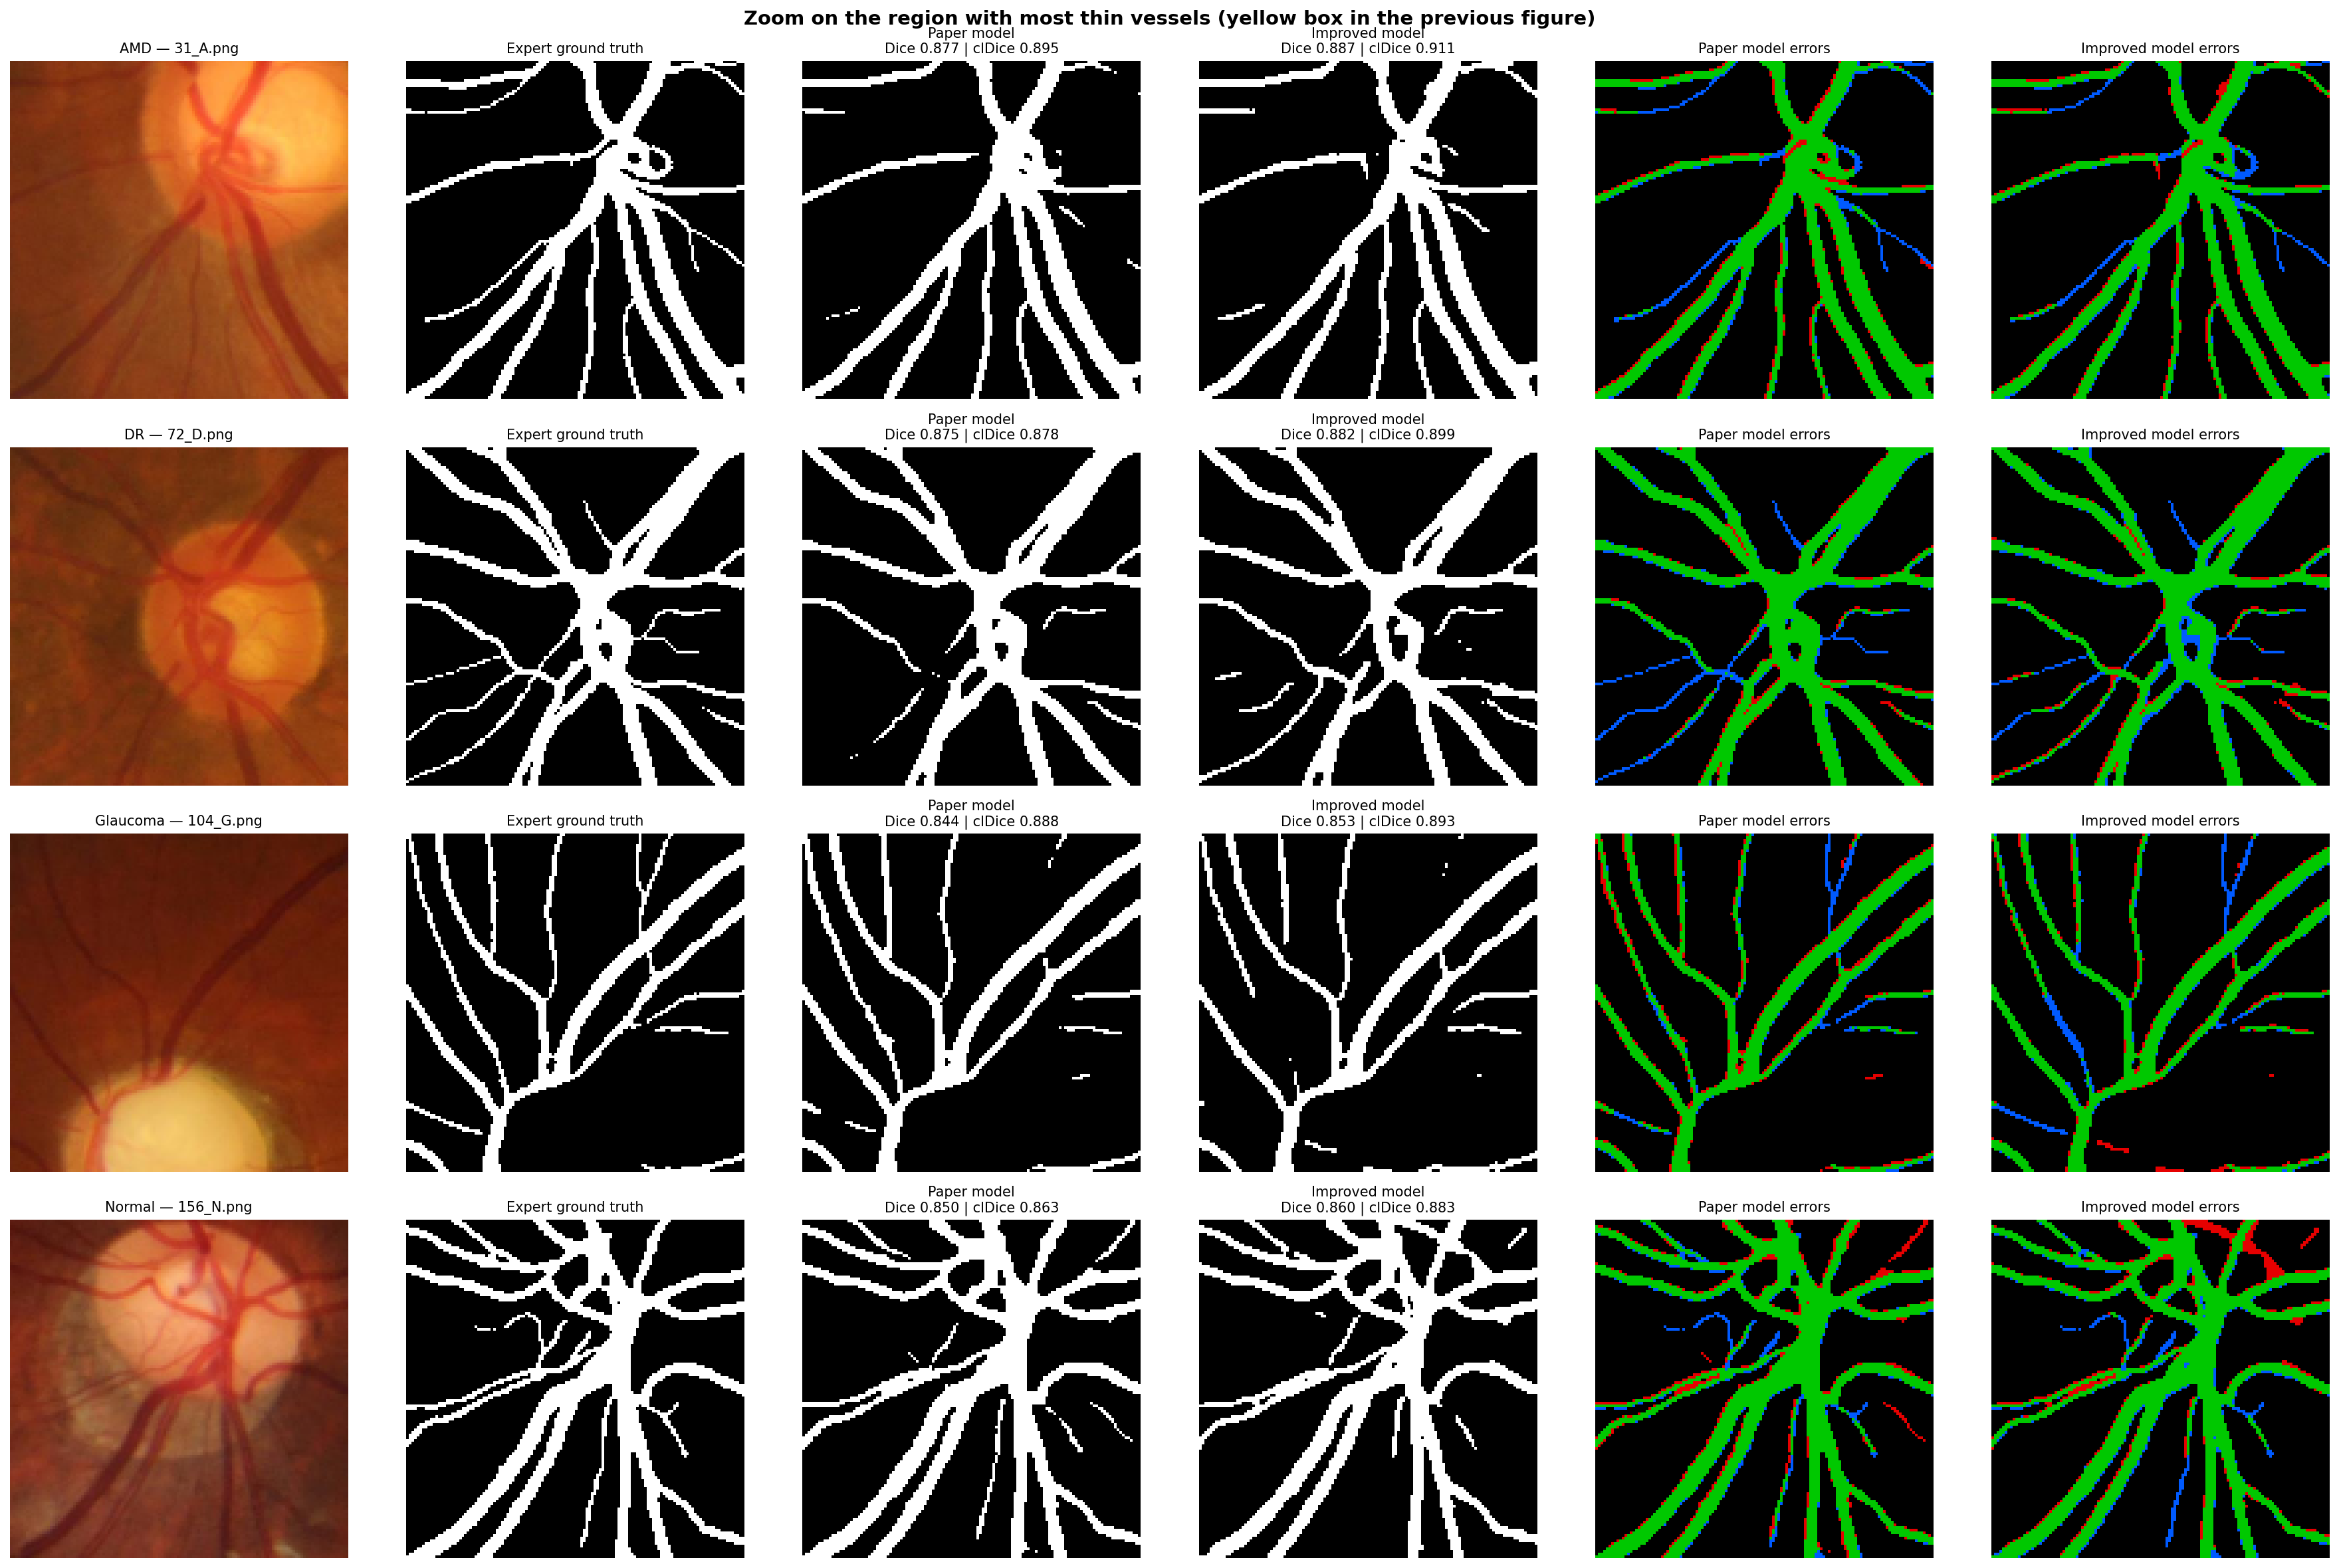

In [18]:
def error_map(pred, gt, fov):
    out = np.zeros((*gt.shape, 3), np.uint8); inside = fov > 0.5
    out[(gt > 0.5) & (pred > 0) & inside] = [0, 200, 0]
    out[(gt <= 0.5) & (pred > 0) & inside] = [230, 0, 0]
    out[(gt > 0.5) & (pred == 0) & inside] = [0, 90, 255]
    return out

def thin_window(gt, size=128):
    thin = ((gt > 0.5) & (distance_transform_edt(gt > 0.5) <= 1.5)).astype(np.float32)
    c = cv2.boxFilter(thin, -1, (size, size), normalize=False, anchor=(0, 0), borderType=cv2.BORDER_CONSTANT)[:gt.shape[0] - size + 1, :gt.shape[1] - size + 1]
    return np.unravel_index(np.argmax(c), c.shape)

pl = live[live.model == LABEL[PAPER]].set_index("filename"); il = live[live.model == LABEL[IMPROVED]].set_index("filename")
examples = [(d, g.sort_values("F1_Dice").index[len(g) // 2]) for d, g in pl.groupby("disease")]
for zoom in [False, True]:
    fig, ax = plt.subplots(4, 6, figsize=(24, 17 if not zoom else 16))
    for r, (d, fname) in enumerate(examples):
        rgb = cv2.cvtColor(cv2.imread(f"data/FIVES_resized/test/images/{fname}"), cv2.COLOR_BGR2RGB)
        it = prepare_eval_item(f"data/FIVES_resized/test/images/{fname}", f"data/FIVES_resized/test/masks/{fname}", 512)
        gt, fov = it["gt"].astype(np.float32), it["fov"].astype(np.float32)
        pp, ipred = preds[fname]
        y, x = thin_window(gt)
        panels = [(rgb, f"{d} — {fname}"), (gt, "Expert ground truth"),
                  (pp, f"Paper model\nDice {pl.loc[fname, 'F1_Dice']:.3f} | clDice {pl.loc[fname, 'clDice']:.3f}"),
                  (ipred, f"Improved model\nDice {il.loc[fname, 'F1_Dice']:.3f} | clDice {il.loc[fname, 'clDice']:.3f}"),
                  (error_map(pp, gt, fov), "Paper model errors"), (error_map(ipred, gt, fov), "Improved model errors")]
        for c, (im, title) in enumerate(panels):
            shown = im[y:y + 128, x:x + 128] if zoom else im
            ax[r, c].imshow(shown, cmap="gray" if shown.ndim == 2 else None, interpolation="nearest")
            ax[r, c].set_title(title, fontsize=10); ax[r, c].axis("off")
        if not zoom:
            ax[r, 0].add_patch(plt.Rectangle((x, y), 128, 128, fill=False, edgecolor="yellow", lw=1.5))
    plt.suptitle("Zoom on the region with most thin vessels (yellow box in the previous figure)" if zoom else
                 "Typical test image per disease — green: correct, red: false vessel, blue: missed vessel", fontweight="bold", fontsize=14)
    plt.tight_layout(); plt.show()

---
## 14. Training behaviour

Validation Dice and sensitivity during training (mean ± std over 3 seeds; validation = 120 full images, 30 per disease, always scored at 512×512).

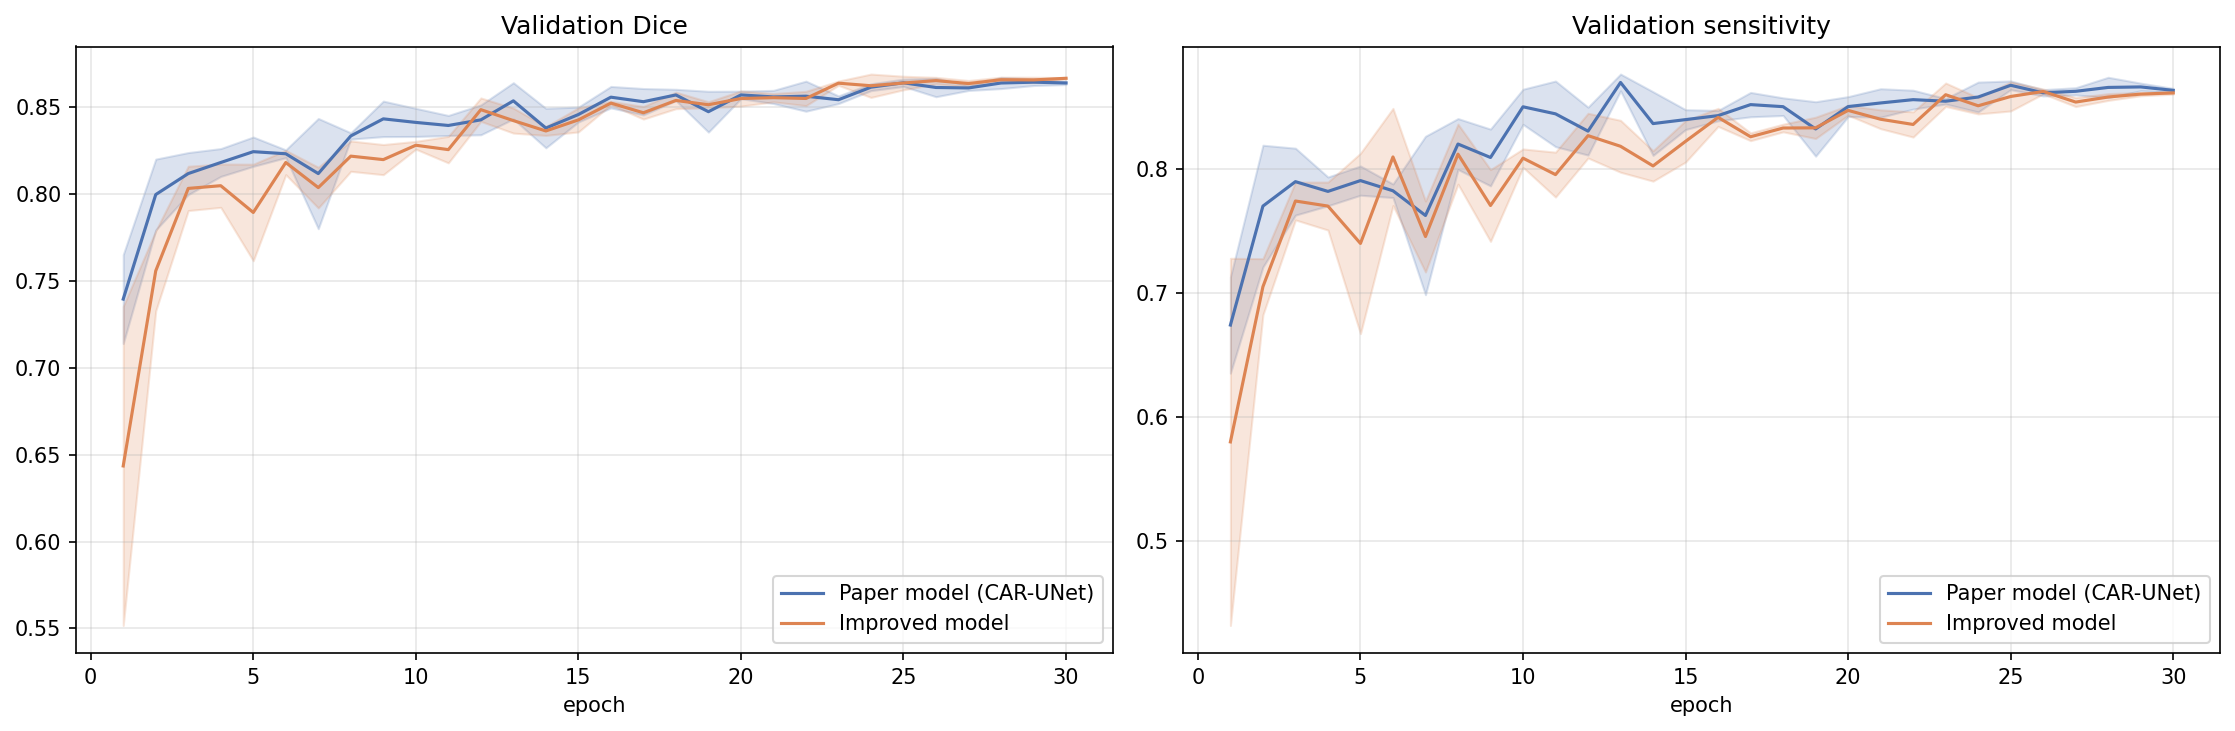

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
for key in [PAPER, IMPROVED]:
    H = [json.load(open(f"{RUNS}/{key}_seed{s}/history.json")) for s in SEEDS]
    for a, m in zip(ax, ["val_dice", "val_sensitivity"]):
        v = np.array([h[m][:30] for h in H]); e = np.arange(1, 31)
        a.plot(e, v.mean(0), label=LABEL[key], color=COLORS[LABEL[key]])
        a.fill_between(e, v.mean(0) - v.std(0), v.mean(0) + v.std(0), alpha=0.2, color=COLORS[LABEL[key]])
ax[0].set_title("Validation Dice"); ax[1].set_title("Validation sensitivity")
for a in ax: a.set_xlabel("epoch"); a.legend()
plt.tight_layout(); plt.show()

---
## 15. Key findings (inference points)

The numbers below are computed from the results above.

In [20]:
d_gain = I["F1_Dice"].mean() - P["F1_Dice"].mean()
c_gain = I["clDice"].mean() - P["clDice"].mean()
s_gain = I["Sensitivity"].mean() - P["Sensitivity"].mean()
pr_gain = I["Precision"].mean() - P["Precision"].mean()
c_better = int((ic > pc).sum()); d_better = int((ia > pa).sum())
hi_gain = np.mean(hi[LABEL[IMPROVED]]["Dice"]) - np.mean(hi[LABEL[PAPER]]["Dice"])
tv_gain = tv[LABEL[IMPROVED]] - tv[LABEL[PAPER]]
best_d = dis["change F1_Dice"].idxmax(); worst_d = dis["change F1_Dice"].idxmin()
findings = [
    f"1. The improved model beats the paper model on Dice ({d_gain * 100:+.2f} points), sensitivity ({s_gain * 100:+.2f}), connectivity/clDice ({c_gain * 100:+.2f}) and AUC; precision changes by {pr_gain * 100:+.2f} points.",
    f"2. The gains are statistically significant: the improved model has better connectivity on {c_better}/200 test images and better Dice on {d_better}/200 (Wilcoxon p << 0.05), and it is better in every training seed.",
    f"3. The clearest gains are on THIN vessels: thin-vessel recall {tv_gain * 100:+.2f} points (seed 0), and {hi_gain * 100:+.2f} Dice points when scored against the 1024x1024 ground truth.",
    "4. Each improvement has a clear role (ablation): dual attention -> fewer false vessels and higher Dice; clDice loss -> connected vessels and higher sensitivity; 1024 resolution -> thin vessels and higher precision; tuned threshold -> converts that precision into more vessels found.",
    f"5. Per disease, the largest Dice gain is on {best_d} images ({dis.loc[best_d, 'change F1_Dice'] * 100:+.2f} points); {worst_d} images change least ({dis.loc[worst_d, 'change F1_Dice'] * 100:+.2f}) and remain the hardest group.",
    f"6. The improved model has almost the same size ({n_improved:,} vs {n_paper:,} parameters, +{n_improved - n_paper:,}) but needs ~1.6x training time and ~4x more inference tiles because it works at 1024x1024.",
    "7. Honest negative result: test-time augmentation (averaging flipped predictions) lowered Dice for most models, so it is only used when the validation set shows a gain.",
    "8. Limitations: two very low-quality test images (122_G, 123_G) fail for both models (Dice < 0.1), and the Glaucoma group is not improved.",
]
print("\n\n".join(findings))
print(f"\nNotebook run time: {(time.time() - NOTEBOOK_START) / 60:.1f} min")

1. The improved model beats the paper model on Dice (+0.54 points), sensitivity (+1.55), connectivity/clDice (+1.25) and AUC; precision changes by -0.40 points.

2. The gains are statistically significant: the improved model has better connectivity on 175/200 test images and better Dice on 140/200 (Wilcoxon p << 0.05), and it is better in every training seed.

3. The clearest gains are on THIN vessels: thin-vessel recall +0.77 points (seed 0), and +2.24 Dice points when scored against the 1024x1024 ground truth.

4. Each improvement has a clear role (ablation): dual attention -> fewer false vessels and higher Dice; clDice loss -> connected vessels and higher sensitivity; 1024 resolution -> thin vessels and higher precision; tuned threshold -> converts that precision into more vessels found.

5. Per disease, the largest Dice gain is on Normal images (+1.78 points); Glaucoma images change least (-0.11) and remain the hardest group.

6. The improved model has almost the same size (32,436,

---
### Where everything is

| What | Where |
|---|---|
| Improvement code | `src/car_unet.py` (dual attention), `src/losses.py` (clDice loss), `scripts/train_fives.py` (1024 resolution), `scripts/evaluate_post.py` (threshold / TTA) |
| Full report | `IMPROVEMENTS.md` |
| All result tables and tests | `results/RESULTS_TABLE.md`, `results/POST_RESULTS.md` |
| Trained models | `models/` (3 seeds per model) |
| Reproduce training | `python scripts/run_baselines.py --models car_unet car_unet_da car_unet_da_cldice car_unet_da_cldice_1024` (~25 h on an RTX 4050 laptop GPU) |
| Rebuild this notebook | `python scripts/build_comparison_notebook.py` then run it (~10–15 min) |